# Label-quality sanity check — all downstream probes

Audits every label the frozen-encoder probe menu is scored on, not just the v1 four.
Motivated by two defects that surfaced by accident rather than by design:

* `rotation` is confounded on the v1 subset — `subset.py:90` defines quiet as *matched in no
  catalog*, **including rotation**, so 0 of 10,000 quiet stars are rotation-positive against a
  corpus rate of ~13%. Every rotation number is partly a general-variability detector.
* `ijspeert2024` is ~80% re-asked `eb` — 74 of 93 test positives are Villanova EBs.

**This notebook is report-only.** It never writes a label file. A FAIL writes a row in
`labels/qc/label_quality_report.csv`; changing a label version is a separate, explicit act
(an eval-time `readout_sweep --labels-version` override) that needs its own ADR.

Thresholds are **pre-registered** in `labels/qc/label_quality_gates.yaml`, fixed before any
measurement, so a verdict cannot be rationalised after seeing the number.

| § | content |
|---|---|
| 0 | knobs, gate manifest, task registry, helpers, npz index |
| 0.5 | compute pass (cached) |
| 1 | support & prevalence |
| 2 | cross-task overlap matrix |
| 3 | negative-pool construction |
| 4 | target redundancy |
| 5 | resolvability — period containment / frequency vs Δf |
| 6 | event coverage (observed ÷ ephemeris-expected) |
| 7 | signal presence, family-specific |
| 8 | pipeline censoring |
| 9 | gallery — per-task visual inspection |
| 10 | gate report |
| 11 | join to exp05 scores (interpretive) |

Env: `astro` (CPU only — no encoder, no torch; safe to run beside a GPU training job).

## 0. Setup

Knobs live here and nowhere else. `FORCE_RECOMPUTE=False` reuses the parquet caches under
`labels/qc/cache/`, so re-running to tweak a plot takes seconds; set `TASKS` to a list of names
to recompute just those.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- knobs -----------------------------------------------------------------
N_SAMPLE = 300           # positives (and matched negatives) drawn per task
MAX_NPZ_PER_STAR = 8     # cap on files read per star; keeps the pass CPU-light
FORCE_RECOMPUTE = False  # True re-runs the compute pass even if caches exist
CACHE_VERSION = 2        # bump when a measurement definition changes; old caches are then ignored
TASKS = None             # None = all; or e.g. ["eb", "pulsating"]

# --- paths -----------------------------------------------------------------
ROOT = Path.cwd()
while not (ROOT / "CLAUDE.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

SEQ_DIR = ROOT / "processed" / "sequences"
QC = ROOT / "labels" / "qc"
CACHE = QC / "cache"
FIGS = QC / "figs"
CACHE.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

GATES = yaml.safe_load((QC / "label_quality_gates.yaml").read_text(encoding="utf-8"))

# --- geometry, recomputed and asserted against the manifest ----------------
CAD_S = GATES["geometry"]["cadence_seconds"]
W = GATES["geometry"]["window_cadences"]
SEQ_LEN = GATES["geometry"]["seq_len"]

WINDOW_SPAN_D = W * CAD_S / 86400.0
SEQ_SPAN_D = W * SEQ_LEN * CAD_S / 86400.0
WINDOW_DF_UHZ = 1e6 / (W * CAD_S)
SEQ_DF_UHZ = 1e6 / (W * SEQ_LEN * CAD_S)

assert abs(WINDOW_SPAN_D * 24 - GATES["geometry"]["window_span_hours"]) < 0.02
assert abs(WINDOW_DF_UHZ - GATES["geometry"]["window_delta_f_uhz"]) < 0.02
assert abs(SEQ_DF_UHZ - GATES["geometry"]["sequence_delta_f_uhz"]) < 0.02

print(f"root                {ROOT}")
print(f"window span         {WINDOW_SPAN_D * 24:.2f} h   -> delta_f {WINDOW_DF_UHZ:.2f} uHz")
print(f"sequence span       {SEQ_SPAN_D:.2f} d   -> delta_f {SEQ_DF_UHZ:.2f} uHz")
print(f"gate manifest v{GATES['version']} ({GATES['date']})")

root                C:\git_repo\Stellar-World-Model
window span         34.13 h   -> delta_f 8.14 uHz
sequence span       5.69 d   -> delta_f 2.03 uHz
gate manifest v1 (2026-07-28)


### 0.1 Label sources

Seven files, three granularities. The v1 CSV has three versions that differ **only** in which
`transit`/`eb` positives the Phase-0 filters switch off; `docs/labels-sources.md` records the base
file as canonical and v2/v3 as audited-but-unpromoted alternatives. This notebook audits the
**base** file and carries v2/v3 as hypotheses under test — loading v2 would make it impossible to
re-derive whether the coverage filter was right.

In [2]:
LABELS_V1 = pd.read_csv(ROOT / "labels" / "variability_labels_star.csv")
LABELS_V2 = pd.read_csv(ROOT / "labels" / "variability_labels_star_v2.csv")
LABELS_V3 = pd.read_csv(ROOT / "labels" / "variability_labels_star_v3.csv")
NEW_TASK = pd.read_csv(ROOT / "labels" / "new_task_labels_star.csv")

EXT = ROOT / "labels" / "external"
IJSPEERT = pd.read_csv(EXT / "ijspeert2024_bright.csv")
KOUNKEL = pd.read_csv(EXT / "kounkel2022.csv")
SREENIVAS = pd.read_csv(EXT / "sreenivas2025.csv")
HATT = pd.read_csv(EXT / "hatt2023.csv")
HON = pd.read_csv(EXT / "hon2021.csv")

TOI = pd.read_csv(QC / "toi_nasa.csv")
FLARE_WIN = pd.read_parquet(QC / "flare_window_labels_pool.parquet")

SUBSET_V1 = pd.read_parquet(ROOT / "processed" / "subset" / "subset_tics.parquet")
POOL_NEW = pd.read_parquet(ROOT / "processed" / "subset" / "new_task_pool.parquet")
OUTLIERS = pd.read_csv(ROOT / "processed" / "flux_outliers_cleanup_manifest.csv")

# TOI ephemerides, restricted to the locked v1 disposition whitelist
TOI_WL = TOI[TOI["tfopwg_disp"].isin(["CP", "KP", "PC", "APC"])].copy()
TOI_WL["t0_btjd"] = TOI_WL["pl_tranmid"] - 2457000.0      # BJD -> BTJD, the npz time system
TOI_WL["dur_d"] = TOI_WL["pl_trandurh"] / 24.0
TOI_EPH = (
    TOI_WL.dropna(subset=["pl_orbper", "t0_btjd"])
    .sort_values("pl_orbper")
    .groupby("tid", as_index=False)
    .first()[["tid", "pl_orbper", "t0_btjd", "dur_d", "tfopwg_disp"]]
    .rename(columns={"tid": "tic_id", "pl_orbper": "period"})
)

for name, df in [("v1", LABELS_V1), ("v2", LABELS_V2), ("v3", LABELS_V3)]:
    print(f"{name:3s} rows={len(df):>7,}  transit={int(df.transit.sum()):>5}  eb={int(df.eb.sum()):>5}")
print()
print(f"new_task_labels_star  {NEW_TASK.shape}")
print(f"TOI whitelisted ephemerides  {len(TOI_EPH):,} of {len(TOI):,} TOI rows")
print(f"flare window pool     {FLARE_WIN.shape}  positives={int(FLARE_WIN.label.sum()):,}")
print(f"absmax-censored files {len(OUTLIERS):,}")

v1  rows=195,883  transit=  888  eb= 1936
v2  rows=195,883  transit=  724  eb= 1903
v3  rows=195,883  transit=  524  eb= 1936

new_task_labels_star  (11007, 10)
TOI whitelisted ephemerides  6,351 of 8,064 TOI rows
flare window pool     (32684, 5)  positives=525
absmax-censored files 677


### 0.2 Task registry

One entry per probe. Everything downstream iterates this, so adding a 17th probe is one entry,
not one section.

`family` decides which signal test, resolvability check and censoring check apply — a fold at the
catalogued period is meaningless for a stochastic power excess, and a PSD excess is meaningless
for an eclipse.

| family | what the signal looks like | signal test | resolvability |
|---|---|---|---|
| `eclipse_like` | localized repeating dips | fold at P, depth/scatter SNR | event coverage |
| `coherent_periodic` | sustained coherent oscillation | Lomb–Scargle FAP at catalogued P | period ≤ window span |
| `stochastic_power_excess` | broad power hump near ν<sub>max</sub> | PSD excess vs local background | ν ≥ 3·Δf |
| `transient` | isolated positive excursions | ≥1 >5σ positive excursion | none (no ephemeris) |

In [3]:
def _pos(df: pd.DataFrame, col: str) -> np.ndarray:
    """TIC ids where `col` == 1, NaN-safe."""
    return df.loc[df[col] == 1, "tic_id"].astype("int64").to_numpy()


# ijspeert positives, and the same minus every Villanova EB (the 80%-overlap control)
IJ_TICS = IJSPEERT["TIC"].astype("int64").to_numpy()
EB_TICS = set(_pos(LABELS_V1, "eb").tolist())
IJ_EXCL = np.array([t for t in IJ_TICS if t not in EB_TICS], dtype="int64")

KOUNKEL_P = (
    KOUNKEL.dropna(subset=["Per"])
    .groupby("TIC", as_index=False)["Per"].median()
    .rename(columns={"TIC": "tic_id", "Per": "period"})
)
SREEN_NUMAX = (
    SREENIVAS.dropna(subset=["numax"])
    .groupby("TIC", as_index=False)["numax"].median()
    .rename(columns={"TIC": "tic_id", "numax": "freq_uhz"})
)

REGISTRY = [
    # ---- v1 variability -------------------------------------------------
    dict(task="transit", family="eclipse_like", kind="detection", source="variability_labels_star.csv",
         positives=_pos(LABELS_V1, "transit"),
         positive_rule="tfopwg_disp in {CP,KP,PC,APC} (ADR-0009 whitelist)",
         negative_rule="quiet pool (matched in NO catalog)",
         eph="toi", period_col=None),
    dict(task="eb", family="eclipse_like", kind="detection", source="variability_labels_star.csv",
         positives=_pos(LABELS_V1, "eb"),
         positive_rule="Villanova/Prsa+2022 only, strictly 0/1 (ADR-0007)",
         negative_rule="quiet pool",
         eph="fold", period_col="eb_period"),
    dict(task="pulsating", family="coherent_periodic", kind="detection", source="variability_labels_star.csv",
         positives=_pos(LABELS_V1, "pulsating"),
         positive_rule="Gao+2025 only, no negative mask",
         negative_rule="quiet pool",
         eph=None, period_col="pulsating_period"),
    dict(task="rotation", family="coherent_periodic", kind="detection", source="variability_labels_star.csv",
         positives=_pos(LABELS_V1, "rotation"),
         positive_rule="TARS rotation detection",
         negative_rule="quiet pool -- CONFOUNDED: quiet excludes rotation, so 0/10,000 negatives",
         eph=None, period_col="rotation_period"),
    dict(task="rotation_period", family="coherent_periodic", kind="regression", source="variability_labels_star.csv",
         positives=LABELS_V1.loc[(LABELS_V1.rotation == 1) & LABELS_V1.rotation_period.notna(), "tic_id"].to_numpy(),
         positive_rule="rotation==1 and rotation_period present (P<=5 d scope, ADR-0004)",
         negative_rule="n/a (regression on positives only)",
         eph=None, period_col="rotation_period"),
    dict(task="flare_ever", family="transient", kind="detection", source="variability_labels_star.csv",
         positives=_pos(LABELS_V1, "flare_ever"),
         positive_rule="flatwrm2 >=1 flare in any sector",
         negative_rule="quiet pool",
         eph=None, period_col=None),
    # ---- new-task pool ---------------------------------------------------
    dict(task="osc_giant", family="stochastic_power_excess", kind="detection", source="new_task_labels_star.csv",
         positives=_pos(NEW_TASK, "osc_giant"),
         positive_rule="Hon+2021 oscillation detection in a red giant",
         negative_rule="quiet pool -- positives are giants, negatives are random quiet stars (unmatched)",
         eph=None, freq_col="numax_hon"),
    dict(task="solar_like_osc", family="stochastic_power_excess", kind="detection", source="new_task_labels_star.csv",
         positives=_pos(NEW_TASK, "solar_like_osc"),
         positive_rule="Hatt+2023 solar-like oscillator",
         negative_rule="quiet pool (unmatched)",
         eph=None, freq_col="numax_hatt"),
    dict(task="numax_hon", family="stochastic_power_excess", kind="regression", source="new_task_labels_star.csv",
         positives=NEW_TASK.loc[NEW_TASK.numax_hon.notna(), "tic_id"].to_numpy(),
         positive_rule="Hon+2021 numax present",
         negative_rule="n/a (regression)",
         eph=None, freq_col="numax_hon"),
    dict(task="numax_hatt", family="stochastic_power_excess", kind="regression", source="new_task_labels_star.csv",
         positives=NEW_TASK.loc[NEW_TASK.numax_hatt.notna(), "tic_id"].to_numpy(),
         positive_rule="Hatt+2023 numax present",
         negative_rule="n/a (regression)",
         eph=None, freq_col="numax_hatt"),
    dict(task="dnu_hatt", family="stochastic_power_excess", kind="regression", source="new_task_labels_star.csv",
         positives=NEW_TASK.loc[NEW_TASK.dnu_hatt.notna(), "tic_id"].to_numpy(),
         positive_rule="Hatt+2023 large frequency separation present",
         negative_rule="n/a (regression)",
         eph=None, freq_col="dnu_hatt"),
    dict(task="rgb_vs_heb", family="stochastic_power_excess", kind="contrastive", source="new_task_labels_star.csv",
         positives=_pos(NEW_TASK, "rgb_vs_heb"),
         positive_rule="Sreenivas+2025 evolutionary state = HeB",
         negative_rule="Sreenivas+2025 state = RGB -- the ONLY task with a matched negative pool",
         eph=None, freq_col=None, external_freq=SREEN_NUMAX),
    dict(task="prot_kounkel", family="coherent_periodic", kind="regression", source="new_task_labels_star.csv",
         positives=NEW_TASK.loc[NEW_TASK.prot_kounkel.notna(), "tic_id"].to_numpy(),
         positive_rule="Kounkel+2022 rotation period present",
         negative_rule="n/a (regression)",
         eph=None, period_col=None, external_period=KOUNKEL_P),
    # ---- external-only ---------------------------------------------------
    dict(task="ijspeert", family="eclipse_like", kind="detection", source="external/ijspeert2024_bright.csv",
         positives=IJ_TICS,
         positive_rule="Ijspeert+2024 eclipsing-binary candidate (Tmag<10 cut)",
         negative_rule="quiet pool",
         eph=None, period_col=None),
    dict(task="ijspeert_excl_villanova", family="eclipse_like", kind="detection", source="external/ijspeert2024_bright.csv",
         positives=IJ_EXCL,
         positive_rule="Ijspeert+2024 minus every Villanova EB",
         negative_rule="quiet pool",
         eph=None, period_col=None),
    # ---- window-level ----------------------------------------------------
    dict(task="flare", family="transient", kind="detection", source="qc/flare_window_labels_pool.parquet",
         positives=FLARE_WIN.loc[FLARE_WIN.label == 1, "tic_id"].astype("int64").unique(),
         positive_rule="window-level flare detection (flatwrm2 epoch inside the window)",
         negative_rule="quiet pool",
         eph=None, period_col=None),
]

REG = {r["task"]: r for r in REGISTRY}
reg_tbl = pd.DataFrame([
    {"task": r["task"], "family": r["family"], "kind": r["kind"],
     "n_pos_corpus": len(r["positives"]), "source": r["source"]}
    for r in REGISTRY
])
display(reg_tbl)
print(f"{len(REGISTRY)} registry entries; flare_ever is excluded from v1 metrics (ADR-0001) "
      "but audited here as supplementary.")

,task,family,kind,n_pos_corpus,source
0,transit,eclipse_like,detection,888,variability_labels_star.csv
1,eb,eclipse_like,detection,1936,variability_labels_star.csv
2,pulsating,coherent_periodic,detection,2050,variability_labels_star.csv
3,rotation,coherent_periodic,detection,25369,variability_labels_star.csv
4,rotation_period,coherent_periodic,regression,25369,variability_labels_star.csv
5,flare_ever,transient,detection,3119,variability_labels_star.csv
6,osc_giant,stochastic_power_excess,detection,8789,new_task_labels_star.csv
7,solar_like_osc,stochastic_power_excess,detection,2757,new_task_labels_star.csv
8,numax_hon,stochastic_power_excess,regression,8789,new_task_labels_star.csv
9,numax_hatt,stochastic_power_excess,regression,2757,new_task_labels_star.csv


16 registry entries; flare_ever is excluded from v1 metrics (ADR-0001) but audited here as supplementary.


### 0.3 Label matrix

Long form `tic_id × task`, joined from all seven sources, stamped with each source's mtime.

**This is a view, never a label source.** It is regenerated on every run, and nothing may edit it.
The mtime stamp is the guard against the confusion that produced the three-versions question — the
artifact records exactly which files it was built from.

In [4]:
def _mtime(p: Path) -> str:
    return pd.Timestamp(p.stat().st_mtime, unit="s").strftime("%Y-%m-%d %H:%M")


SOURCE_PATHS = {
    "variability_labels_star.csv": ROOT / "labels" / "variability_labels_star.csv",
    "new_task_labels_star.csv": ROOT / "labels" / "new_task_labels_star.csv",
    "external/ijspeert2024_bright.csv": EXT / "ijspeert2024_bright.csv",
    "qc/flare_window_labels_pool.parquet": QC / "flare_window_labels_pool.parquet",
}

rows = []
for r in REGISTRY:
    p = SOURCE_PATHS[r["source"]]
    rows.append(pd.DataFrame({
        "tic_id": np.asarray(r["positives"], dtype="int64"),
        "task": r["task"],
        "family": r["family"],
        "kind": r["kind"],
        "value": 1,
        "source_file": r["source"],
        "source_mtime": _mtime(p),
    }))
LABEL_MATRIX = pd.concat(rows, ignore_index=True).drop_duplicates(["tic_id", "task"])
LABEL_MATRIX.to_parquet(QC / "label_matrix.parquet", index=False)

# wide boolean pivot, used by the overlap matrix
WIDE = (
    LABEL_MATRIX.assign(v=True)
    .pivot_table(index="tic_id", columns="task", values="v", aggfunc="first", fill_value=False)
    .astype(bool)
)

print(f"label_matrix.parquet  {LABEL_MATRIX.shape}  ({LABEL_MATRIX.tic_id.nunique():,} distinct TICs)")
display(LABEL_MATRIX.groupby(["source_file", "source_mtime"]).size().rename("rows").reset_index())

label_matrix.parquet  (102501, 7)  (46,403 distinct TICs)


,source_file,source_mtime,rows
0,external/ijspeert2024_bright.csv,2026-07-21 22:59,15755
1,new_task_labels_star.csv,2026-07-23 02:47,27623
2,qc/flare_window_labels_pool.parquet,2026-07-23 03:27,392
3,variability_labels_star.csv,2026-05-30 22:38,58731


### 0.4 Window index and signal helpers

`processed/sequences/` holds 416,729 `.npz` files named `TIC{tic:010d}_s{sector}_seg{seg}_run{run}.npz`.
Globbing per star would be hopeless, so the directory is scanned once into a cached index.

**Two facts about the stored arrays that the tests below pin down:**

1. `times` is float32 at BTJD ≈ 2334, where one ulp is ~21 s. Consecutive 120 s cadences therefore
   quantize to 5 or 6 ulp, and `median(diff(times))` reads 126.6 s rather than 120 s. Anything
   needing exact spacing (the PSD) must use the nominal cadence, not the differenced times.
2. One `.npz` is `SEQ_LEN` **contiguous** windows of a single segment — 4096 cadences = 5.69 d — so
   it can be flattened for a uniformly-sampled periodogram. Different files cannot.

In [5]:
_PAT = re.compile(r"TIC(\d+)_s(\d+)_seg(\d+)_run(\d+)\.npz$")


def build_npz_index(force: bool = False) -> pd.DataFrame:
    """Scan processed/sequences once into tic_id -> file index. Cached."""
    cache = CACHE / "npz_index.parquet"
    if cache.exists() and not force:
        return pd.read_parquet(cache)
    recs = []
    import os
    for e in tqdm(os.scandir(SEQ_DIR), desc="index:scan", unit="file"):
        m = _PAT.search(e.name)
        if m:
            recs.append((int(m.group(1)), int(m.group(2)), int(m.group(3)), int(m.group(4)), e.name))
    idx = pd.DataFrame(recs, columns=["tic_id", "sector", "seg_idx", "run_idx", "fname"])
    idx.to_parquet(cache, index=False)
    return idx


NPZ_INDEX = build_npz_index(force=FORCE_RECOMPUTE)
BY_TIC = {t: g["fname"].to_numpy() for t, g in NPZ_INDEX.groupby("tic_id")}
HAS_WINDOWS = np.array(sorted(BY_TIC.keys()), dtype="int64")
print(f"npz index  {len(NPZ_INDEX):,} files over {len(BY_TIC):,} stars")


def load_star(tic: int, max_files: int = MAX_NPZ_PER_STAR):
    """Return (chunks, concatenated t, concatenated f, sector spans).

    A chunk is one contiguous (t, f) block = one .npz = SEQ_LEN tiled windows.
    `spans` is [(lo, hi)] per SECTOR we hold for this star -- the denominator for
    event coverage. See the note in section 6 on why the span must be per-sector
    and not global.
    """
    names = BY_TIC.get(int(tic))
    if names is None:
        return [], np.array([]), np.array([]), []
    chunks, by_sector = [], {}
    for n in names[:max_files]:
        d = np.load(SEQ_DIR / n)
        t = d["times"].reshape(-1).astype("float64")
        f = d["windows"].reshape(-1).astype("float64")
        ok = np.isfinite(t) & np.isfinite(f)
        if ok.sum() > 64:
            t, f = t[ok], f[ok]
            chunks.append((t, f))
            s = int(d["sector"])
            lo, hi = by_sector.get(s, (t.min(), t.max()))
            by_sector[s] = (min(lo, t.min()), max(hi, t.max()))
    if not chunks:
        return [], np.array([]), np.array([]), []
    tt = np.concatenate([c[0] for c in chunks])
    ff = np.concatenate([c[1] for c in chunks])
    o = np.argsort(tt)
    return chunks, tt[o], ff[o], sorted(by_sector.values())

npz index  416,729 files over 119,754 stars


In [6]:
# --- signal tests, one per family ------------------------------------------

def fold_snr(t: np.ndarray, f: np.ndarray, period: float, nbins: int = 100):
    """Eclipse-like: depth of the deepest phase bin over the out-of-eclipse scatter.

    Returns (snr, phase_of_minimum). Flux is MAD-normalized per segment upstream,
    so the scatter is O(1) and the SNR is directly comparable across stars.
    """
    if not np.isfinite(period) or period <= 0 or len(t) < 200:
        return np.nan, np.nan
    ph = ((t - t[0]) / period) % 1.0
    b = np.clip((ph * nbins).astype(int), 0, nbins - 1)
    prof = np.full(nbins, np.nan)
    for k in range(nbins):
        m = b == k
        if m.sum() >= 3:
            prof[k] = np.median(f[m])
    ok = np.isfinite(prof)
    if ok.sum() < nbins // 2:
        return np.nan, np.nan
    base = np.median(prof[ok])
    scat = 1.4826 * np.median(np.abs(prof[ok] - base))
    if scat <= 0:
        return np.nan, np.nan
    kmin = int(np.nanargmin(prof))
    return float((base - prof[kmin]) / scat), float((kmin + 0.5) / nbins)


def ls_fap(t: np.ndarray, f: np.ndarray, period: float):
    """Coherent-periodic: Lomb-Scargle FAP at the CATALOGUED period.

    The question is whether the catalogued value is present in our data, not
    whether the star varies at all -- so the power is evaluated at 1/P, never at
    the best-fit peak.
    """
    from astropy.timeseries import LombScargle
    span = t.max() - t.min() if len(t) else 0.0
    if not np.isfinite(period) or period <= 0 or len(t) < 200 or span < 2 * period:
        return np.nan, np.nan
    ls = LombScargle(t, f)
    p = float(ls.power(1.0 / period))
    try:
        fap = float(ls.false_alarm_probability(p, method="baluev"))
    except Exception:
        fap = np.nan
    return p, fap


def psd_excess(t: np.ndarray, f: np.ndarray, freq_uhz: float):
    """Stochastic: mean PSD power in [0.8, 1.2]*nu_max over the local background.

    Uses the NOMINAL cadence for the sample rate -- the stored float32 times are
    quantized to ~21 s and would bias a differenced estimate (see 0.4).
    """
    from scipy.signal import periodogram
    if not np.isfinite(freq_uhz) or freq_uhz <= 0 or len(f) < 1024:
        return np.nan
    fs = 1.0 / CAD_S
    fr, pw = periodogram(f - np.mean(f), fs=fs, scaling="density")
    fr_uhz = fr * 1e6
    band = (fr_uhz >= 0.8 * freq_uhz) & (fr_uhz <= 1.2 * freq_uhz)
    bkg = ((fr_uhz >= 0.4 * freq_uhz) & (fr_uhz < 0.7 * freq_uhz)) | \
          ((fr_uhz > 1.5 * freq_uhz) & (fr_uhz <= 2.5 * freq_uhz))
    if band.sum() < 2 or bkg.sum() < 5:
        return np.nan
    return float(np.mean(pw[band]) / np.median(pw[bkg]))


def max_excursion(f: np.ndarray):
    """Transient: largest POSITIVE excursion in robust sigma."""
    if len(f) < 128:
        return np.nan
    med = np.median(f)
    mad = 1.4826 * np.median(np.abs(f - med))
    if mad <= 0:
        return np.nan
    return float((f.max() - med) / mad)


def max_dip(f: np.ndarray):
    """Deepest DOWNWARD excursion in robust sigma.

    Unfolded fallback for an eclipse-like catalog that publishes no period (the
    Ijspeert bright extract is TIC/Tmag/score only). Weaker than a fold -- it
    cannot tell a real eclipse from a single bad cadence -- so results using it
    are reported under their own metric name and never scored against the
    pre-registered fold-SNR gate.
    """
    if len(f) < 128:
        return np.nan
    med = np.median(f)
    mad = 1.4826 * np.median(np.abs(f - med))
    if mad <= 0:
        return np.nan
    return float((med - f.min()) / mad)


def _event_mids(lo: float, hi: float, period: float, t0: float) -> np.ndarray:
    k0, k1 = np.ceil((lo - t0) / period), np.floor((hi - t0) / period)
    return t0 + np.arange(k0, k1 + 1) * period if k1 >= k0 else np.array([])


def event_coverage(t: np.ndarray, period: float, t0: float, dur_d: float,
                   spans: list[tuple[float, float]] | None = None):
    """Observed vs ephemeris-expected event count.

    observed = events with >=1 packed cadence within +-dur/2 of mid-time
    expected = events whose mid-time falls inside a span we actually hold

    The choice of span is the whole ballgame:

    * per-SECTOR spans (default when `spans` is given) count only events in
      sectors we downloaded. The ratio then measures PIPELINE loss -- NaN
      discard, segmentation, the outlier guard.
    * the GLOBAL span t.min()..t.max() also counts events in every sector
      BETWEEN the ones we hold. For a star observed in sectors 14 and 60 that is
      years of data we never had, so the ratio collapses toward zero and mostly
      measures survey cadence, not label quality.

    Only the first is a label-quality statement, so it is what the gate reads.
    The second is returned alongside as `baseline_frac` because "how much of the
    full baseline do we hold" is a genuinely useful number -- just a different one.
    """
    if len(t) < 100 or not np.isfinite(period) or period <= 0 or not np.isfinite(t0):
        return np.nan, np.nan, np.nan, np.nan
    dur_d = dur_d if np.isfinite(dur_d) and dur_d > 0 else 0.05 * period
    ts = np.sort(t)

    def _obs(mids: np.ndarray) -> int:
        if not len(mids):
            return 0
        lo = np.searchsorted(ts, mids - dur_d / 2.0)
        return int(np.sum((lo < len(ts)) & (ts[np.clip(lo, 0, len(ts) - 1)] <= mids + dur_d / 2.0)))

    spans = spans or [(float(ts.min()), float(ts.max()))]
    mids_sec = np.concatenate([_event_mids(lo, hi, period, t0) for lo, hi in spans]) \
        if spans else np.array([])
    mids_glob = _event_mids(float(ts.min()), float(ts.max()), period, t0)
    if not len(mids_sec):
        return 0.0, 0.0, np.nan, np.nan
    obs = _obs(mids_sec)
    baseline = len(mids_sec) / len(mids_glob) if len(mids_glob) else np.nan
    return float(obs), float(len(mids_sec)), obs / len(mids_sec), baseline


def duty_cycle(t: np.ndarray):
    """Packed cadences / cadences the span could have held.

    Network-free proxy for total preprocessing loss (NaN discard + segmentation +
    outlier guard combined). Bounds the loss; cannot attribute it to a mechanism.
    """
    if len(t) < 100:
        return np.nan
    span_d = t.max() - t.min()
    expected = span_d * 86400.0 / CAD_S
    return float(len(t) / expected) if expected > 0 else np.nan

#### Inline tests

Synthetic signals with known answers. Each helper must recover the thing it claims to measure
before any of it is pointed at real stars.

In [7]:
_rng = np.random.default_rng(0)  # deterministic ON PURPOSE: these are tests, not samples

# fold_snr recovers an injected box eclipse and misses a pure-noise curve
_t = np.arange(0, 12, CAD_S / 86400.0)
_f = 1.0 + _rng.normal(0, 0.01, _t.size)
_ph = ((_t - _t[0]) / 2.5) % 1.0
_f[(_ph > 0.30) & (_ph < 0.34)] -= 0.20
_snr, _phmin = fold_snr(_t, _f, 2.5)
assert _snr > 20, _snr
assert 0.28 < _phmin < 0.36, _phmin
assert fold_snr(_t, 1.0 + _rng.normal(0, 0.01, _t.size), 2.5)[0] < 6

# ls_fap: a sinusoid at the catalogued period is significant, a wrong period is not
_s = 1.0 + 0.05 * np.sin(2 * np.pi * _t / 1.7) + _rng.normal(0, 0.01, _t.size)
assert ls_fap(_t, _s, 1.7)[1] < 1e-6
assert ls_fap(_t, _s, 0.31)[1] > 1e-6

# psd_excess sees an injected 100 uHz oscillation, and returns ~1 on white noise
_n = 4096
_tt = np.arange(_n) * CAD_S
_osc = 0.02 * np.sin(2 * np.pi * 100e-6 * _tt) + _rng.normal(0, 0.005, _n)
assert psd_excess(None, _osc, 100.0) > 5
assert psd_excess(None, _rng.normal(0, 0.005, _n), 100.0) < 3

# max_excursion finds a spike
_flat = _rng.normal(0, 1.0, 2048)
assert max_excursion(_flat) < 6
_flat[900] = 40.0
assert max_excursion(_flat) > 20

# max_dip is the downward mirror, and must NOT fire on the upward spike above
assert max_dip(_flat) < 6
_flat[1500] = -40.0
assert max_dip(_flat) > 20

# event_coverage: a gap that removes half the epochs halves the ratio
_full = np.arange(0, 20, CAD_S / 86400.0)
assert abs(event_coverage(_full, 2.0, 0.5, 0.1)[2] - 1.0) < 1e-9
_holed = _full[(_full % 4.0) < 2.0]
_o, _e, _r, _b = event_coverage(_holed, 2.0, 0.5, 0.1)
assert 0.4 < _r < 0.6, _r

# ...but the SAME data split into two "sectors" with a long gap between them must
# NOT be penalised for the gap: per-sector spans exclude it, so the ratio is 1.0
# while baseline_frac records that we hold only a fraction of the full baseline.
_s1 = np.arange(0.0, 3.0, CAD_S / 86400.0)
_s2 = np.arange(40.0, 43.0, CAD_S / 86400.0)
_two = np.concatenate([_s1, _s2])
_spans = [(_s1.min(), _s1.max()), (_s2.min(), _s2.max())]
_o2, _e2, _r2, _b2 = event_coverage(_two, 2.0, 0.5, 0.1, _spans)
assert abs(_r2 - 1.0) < 1e-9, _r2                 # nothing was lost inside our sectors
assert _b2 < 0.2, _b2                             # but we hold <20% of the baseline
_o3, _e3, _r3, _b3 = event_coverage(_two, 2.0, 0.5, 0.1)   # global span: looks catastrophic
assert _r3 < 0.2, _r3

# duty_cycle. _holed keeps [0,2) u [4,6) u ... u [16,18): 10 d of data inside an
# 18 d span -- the trailing 18-20 d gap lies beyond t.max() and is not counted,
# which is the intended behaviour (duty cycle is defined on the observed span).
assert abs(duty_cycle(_full) - 1.0) < 0.01
assert abs(duty_cycle(_holed) - 10.0 / 18.0) < 0.01, duty_cycle(_holed)

print("all helper tests passed")

all helper tests passed


## 0.5 Compute pass (cached)

The only expensive step. For each task it draws `N_SAMPLE` positives and `N_SAMPLE` quiet
"negatives", reads up to `MAX_NPZ_PER_STAR` files each, and writes one parquet per task.

Negatives are drawn from the **shared 10,000-star quiet pool**, and are run through the *same*
family signal test as the positives — that measurement is what §3 uses to estimate how
contaminated the negative class is.

Everything downstream reads these caches, so a plot edit costs seconds rather than a re-read of
the corpus.

In [8]:
QUIET_V1 = SUBSET_V1.loc[SUBSET_V1.stratum == "quiet", "tic_id"].astype("int64").to_numpy()
QUIET_NEW = POOL_NEW.loc[POOL_NEW.stratum == "quiet", "tic_id"].astype("int64").to_numpy()
QUIET_ALL = np.union1d(QUIET_V1, QUIET_NEW)
print(f"quiet pool: v1 {len(QUIET_V1):,} | new-task {len(QUIET_NEW):,} | union {len(QUIET_ALL):,} "
      f"| shared {len(np.intersect1d(QUIET_V1, QUIET_NEW)):,}")


def _ephemeris_for(task: str, tic: int, t: np.ndarray, f: np.ndarray):
    """(period, t0, duration_days, t0_source) for a star, or NaNs if unavailable."""
    r = REG[task]
    if r.get("eph") == "toi":
        p = _lookup(_TOI_IDX, tic, "period")
        if np.isfinite(p):
            return p, _lookup(_TOI_IDX, tic, "t0_btjd"), _lookup(_TOI_IDX, tic, "dur_d"), "toi"
        return np.nan, np.nan, np.nan, "none"
    if r.get("eph") == "fold":
        p = _period_for(task, tic)
        if np.isfinite(p) and len(t) > 200:
            _, phmin = fold_snr(t, f, p)
            if np.isfinite(phmin):
                return p, float(t[0] + phmin * p), 0.05 * p, "fold"
        return p, np.nan, np.nan, "none"
    return np.nan, np.nan, np.nan, "none"


# O(1) lookups -- a boolean scan of the 195,883-row frame per star would cost
# ~4,500 full-table passes over the compute pass.
_V1_IDX = LABELS_V1.drop_duplicates("tic_id").set_index("tic_id")
_NT_IDX = NEW_TASK.drop_duplicates("tic_id").set_index("tic_id")
_TOI_IDX = TOI_EPH.drop_duplicates("tic_id").set_index("tic_id")
_EXT_IDX = {r["task"]: (r["external_period"].drop_duplicates("tic_id").set_index("tic_id")
                        if r.get("external_period") is not None else
                        r["external_freq"].drop_duplicates("tic_id").set_index("tic_id")
                        if r.get("external_freq") is not None else None)
            for r in REGISTRY}


def _lookup(idx: pd.DataFrame | None, tic: int, col: str) -> float:
    if idx is None:
        return np.nan
    try:
        v = float(idx.at[int(tic), col])
    except (KeyError, TypeError, ValueError):
        return np.nan
    return v if np.isfinite(v) else np.nan


def _period_for(task: str, tic: int) -> float:
    r = REG[task]
    if r.get("period_col"):
        return _lookup(_V1_IDX, tic, r["period_col"])
    if r.get("external_period") is not None:
        return _lookup(_EXT_IDX[task], tic, "period")
    return np.nan


def _freq_for(task: str, tic: int) -> float:
    r = REG[task]
    if r.get("freq_col"):
        return _lookup(_NT_IDX, tic, r["freq_col"])
    if r.get("external_freq") is not None:
        return _lookup(_EXT_IDX[task], tic, "freq_uhz")
    return np.nan


def measure_star(task: str, tic: int, is_pos: bool) -> dict | None:
    fam = REG[task]["family"]
    chunks, t, f, spans = load_star(tic)
    if len(t) < 200:
        return None
    rec_spans = spans
    rec = dict(task=task, tic_id=int(tic), is_pos=bool(is_pos), family=fam,
               n_cad=int(len(t)), n_files=len(chunks), span_d=float(t.max() - t.min()),
               duty_cycle=duty_cycle(t))
    period = _period_for(task, tic)
    freq = _freq_for(task, tic)
    rec["period_d"] = period
    rec["freq_uhz"] = freq

    if fam == "eclipse_like":
        p = period if np.isfinite(period) else np.nan
        if REG[task].get("eph") == "toi":
            rec["period_d"] = p = _lookup(_TOI_IDX, tic, "period")
        rec["signal"], _ = fold_snr(t, f, p)
        rec["signal_metric"] = "fold_snr"
        if not np.isfinite(rec["signal"]):
            # no catalogued period -> nothing to fold on. Record the unfolded dip
            # instead so the task appears in the report with a number rather than
            # disappearing, and tag it so section 10 forces FLAG.
            rec["signal"] = max_dip(f)
            rec["signal_metric"] = "max_sigma_dip_unfolded"
        per, t0, dur, src = _ephemeris_for(task, tic, t, f)
        rec["t0_source"] = src
        rec["n_sectors_held"] = len(rec_spans)
        (rec["n_obs_events"], rec["n_exp_events"],
         rec["cov_ratio"], rec["baseline_frac"]) = event_coverage(t, per, t0, dur, rec_spans)
    elif fam == "coherent_periodic":
        _, fap = ls_fap(t, f, period)
        rec["signal"] = -np.log10(fap) if np.isfinite(fap) and fap > 0 else (np.nan if not np.isfinite(fap) else 300.0)
        rec["ls_fap"] = fap
        rec["signal_metric"] = "neg_log10_ls_fap"
    elif fam == "stochastic_power_excess":
        longest = max(chunks, key=lambda c: len(c[0]))
        rec["signal"] = psd_excess(None, longest[1], freq)
        rec["signal_metric"] = "psd_excess"
    elif fam == "transient":
        rec["signal"] = max_excursion(f)
        rec["signal_metric"] = "max_sigma_excursion"
    return rec


def compute_task(task: str) -> pd.DataFrame:
    # N_SAMPLE in the filename: a cache built at n=8 must never be reused at n=300
    out = CACHE / f"measure_{task}_n{N_SAMPLE}_v{CACHE_VERSION}.parquet"
    if out.exists() and not FORCE_RECOMPUTE:
        return pd.read_parquet(out)
    r = REG[task]
    rng = np.random.default_rng()  # fresh draw each recompute
    pos = np.intersect1d(np.asarray(r["positives"], dtype="int64"), HAS_WINDOWS)
    neg = np.setdiff1d(np.intersect1d(QUIET_ALL, HAS_WINDOWS), pos)
    pos_s = rng.choice(pos, min(N_SAMPLE, len(pos)), replace=False) if len(pos) else np.array([], dtype="int64")
    neg_s = rng.choice(neg, min(N_SAMPLE, len(neg)), replace=False) if len(neg) else np.array([], dtype="int64")
    recs = []
    for tic in tqdm(pos_s, desc=f"{task}:pos", total=len(pos_s), leave=False):
        rec = measure_star(task, int(tic), True)
        if rec:
            recs.append(rec)
    for tic in tqdm(neg_s, desc=f"{task}:neg", total=len(neg_s), leave=False):
        rec = measure_star(task, int(tic), False)
        if rec:
            recs.append(rec)
    df = pd.DataFrame(recs)
    df.to_parquet(out, index=False)
    return df


todo = [r["task"] for r in REGISTRY] if TASKS is None else list(TASKS)
MEAS = {}
for task in tqdm(todo, desc="compute pass", total=len(todo)):
    MEAS[task] = compute_task(task)
MEASURED = pd.concat([d for d in MEAS.values() if len(d)], ignore_index=True)
print(f"measured {len(MEASURED):,} star-rows over {MEASURED.task.nunique()} tasks")
display(MEASURED.groupby("task").agg(n_pos=("is_pos", "sum"), n_neg=("is_pos", lambda s: (~s).sum())))

quiet pool: v1 10,000 | new-task 10,000 | union 19,014 | shared 986


compute pass:   0%|          | 0/16 [00:00<?, ?it/s]

transit:pos:   0%|          | 0/300 [00:00<?, ?it/s]

transit:neg:   0%|          | 0/300 [00:00<?, ?it/s]

eb:pos:   0%|          | 0/300 [00:00<?, ?it/s]

...

ijspeert_excl_villanova:neg:   0%|          | 0/300 [00:00<?, ?it/s]

flare:pos:   0%|          | 0/300 [00:00<?, ?it/s]

flare:neg:   0%|          | 0/300 [00:00<?, ?it/s]

measured 9,600 star-rows over 16 tasks


,n_pos,n_neg
task,,
dnu_hatt,300,300
eb,300,300
flare,300,300
flare_ever,300,300
ijspeert,300,300
ijspeert_excl_villanova,300,300
numax_hatt,300,300
numax_hon,300,300
osc_giant,300,300


## 1. Support & prevalence

`n_test_pos` below ~30 makes a probe's seed variance exceed the effect it is measuring — the
pre-registered FAIL threshold. The clearest existing case is `ijspeert_excl_villanova`
(n=19, PR-AUC 0.052→0.332 across four seeds).

Also worth reading: **eval prevalence vs corpus prevalence.** Both eval pools contain a fixed
10,000-star quiet draw beside all the positives, so every task's positive rate at eval time is far
above its rate in the sky. That inflation is not a bug, but it means PR-AUC numbers are not
comparable to any external paper's.

,task,family,kind,n_pos_corpus,n_pos_with_windows,n_test_pos,n_test,prev_corpus,prev_eval,prev_inflation
14,ijspeert_excl_villanova,eclipse_like,detection,7501,726,18,3429,0.03829,0.00525,0.13708
13,ijspeert,eclipse_like,detection,8254,1162,20,3429,0.04214,0.00583,0.13842
5,flare_ever,transient,detection,3119,2022,22,2021,0.01592,0.01089,0.68366
15,flare,transient,detection,392,392,66,3429,0.00200,0.01925,9.61805
11,rgb_vs_heb,stochastic_power_excess,contrastive,713,713,113,3429,0.00364,0.03295,9.05353
0,transit,eclipse_like,detection,888,813,122,2021,0.00453,0.06037,13.31611
12,prot_kounkel,coherent_periodic,regression,1061,1061,159,3429,0.00542,0.04637,8.56073
4,rotation_period,coherent_periodic,regression,25369,14927,180,2021,0.12951,0.08906,0.68770
3,rotation,coherent_periodic,detection,25369,14927,180,2021,0.12951,0.08906,0.68770
1,eb,eclipse_like,detection,1936,1276,196,2021,0.00988,0.09698,9.81253


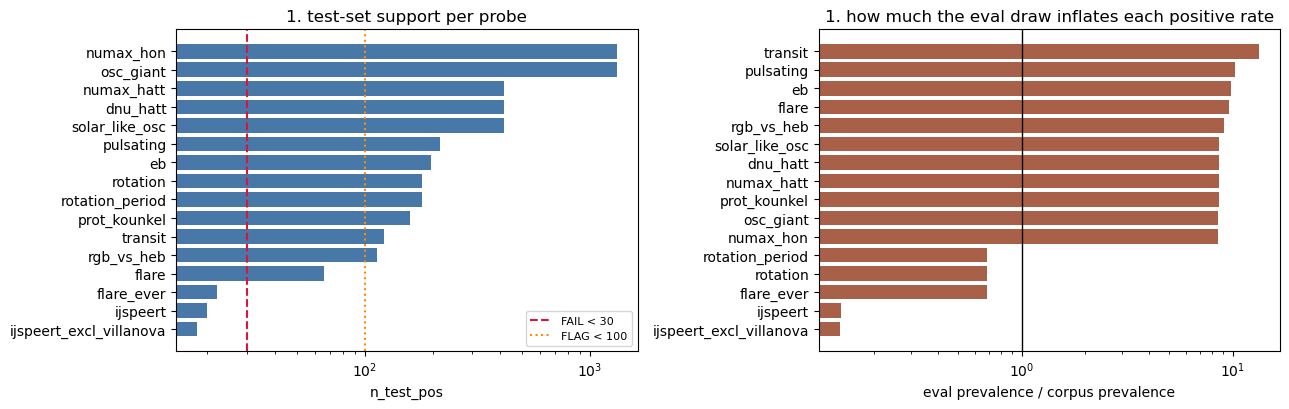

In [9]:
N_CORPUS = LABELS_V1.tic_id.nunique()
EVAL_TEST = {
    "variability_labels_star.csv": set(SUBSET_V1.loc[SUBSET_V1.split == "test", "tic_id"]),
    "new_task_labels_star.csv": set(POOL_NEW.loc[POOL_NEW.split == "test", "tic_id"]),
    "external/ijspeert2024_bright.csv": set(POOL_NEW.loc[POOL_NEW.split == "test", "tic_id"]),
    "qc/flare_window_labels_pool.parquet": set(POOL_NEW.loc[POOL_NEW.split == "test", "tic_id"]),
}
POOL_N = {"variability_labels_star.csv": (SUBSET_V1.split == "test").sum(),
          "new_task_labels_star.csv": (POOL_NEW.split == "test").sum()}
POOL_N["external/ijspeert2024_bright.csv"] = POOL_N["new_task_labels_star.csv"]
POOL_N["qc/flare_window_labels_pool.parquet"] = POOL_N["new_task_labels_star.csv"]

rows = []
for r in REGISTRY:
    pos = set(np.asarray(r["positives"], dtype="int64").tolist())
    test = EVAL_TEST[r["source"]]
    n_test_pos = len(pos & test)
    n_test = int(POOL_N[r["source"]])
    with_win = len(pos & set(HAS_WINDOWS.tolist()))
    rows.append({
        "task": r["task"], "family": r["family"], "kind": r["kind"],
        "n_pos_corpus": len(pos), "n_pos_with_windows": with_win,
        "n_test_pos": n_test_pos, "n_test": n_test,
        "prev_corpus": len(pos) / N_CORPUS,
        "prev_eval": n_test_pos / n_test if n_test else np.nan,
    })
SUPPORT = pd.DataFrame(rows)
SUPPORT["prev_inflation"] = SUPPORT.prev_eval / SUPPORT.prev_corpus
display(SUPPORT.round(5).sort_values("n_test_pos"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
s = SUPPORT.sort_values("n_test_pos")
ax[0].barh(s.task, s.n_test_pos, color="#4878a8")
ax[0].axvline(GATES["generic"]["support"]["fail_below"], color="crimson", ls="--", label="FAIL < 30")
ax[0].axvline(GATES["generic"]["support"]["flag_below"], color="darkorange", ls=":", label="FLAG < 100")
ax[0].set_xscale("log"); ax[0].set_xlabel("n_test_pos"); ax[0].legend(fontsize=8)
ax[0].set_title("1. test-set support per probe")

s2 = SUPPORT.dropna(subset=["prev_inflation"]).sort_values("prev_inflation")
ax[1].barh(s2.task, s2.prev_inflation, color="#a86048")
ax[1].axvline(1.0, color="k", lw=1)
ax[1].set_xscale("log"); ax[1].set_xlabel("eval prevalence / corpus prevalence")
ax[1].set_title("1. how much the eval draw inflates each positive rate")
plt.tight_layout(); plt.savefig(FIGS / "1_support.png", dpi=120, bbox_inches="tight"); plt.show()

## 2. Cross-task overlap

The check that should have been pre-registered before `ijspeert` entered the menu. Two probes
sharing most of their positives are one probe asked twice, and averaging their scores
double-counts whatever the encoder happens to do on that population.

Reported as Jaccard on the full corpus — computing it on the eval subset alone cannot distinguish
real catalog redundancy from a sampling artifact.

`flare` and `flare_ever` are the same phenomenon at two granularities (window-level vs
star-level), so their agreement is a consistency check rather than a contamination one.

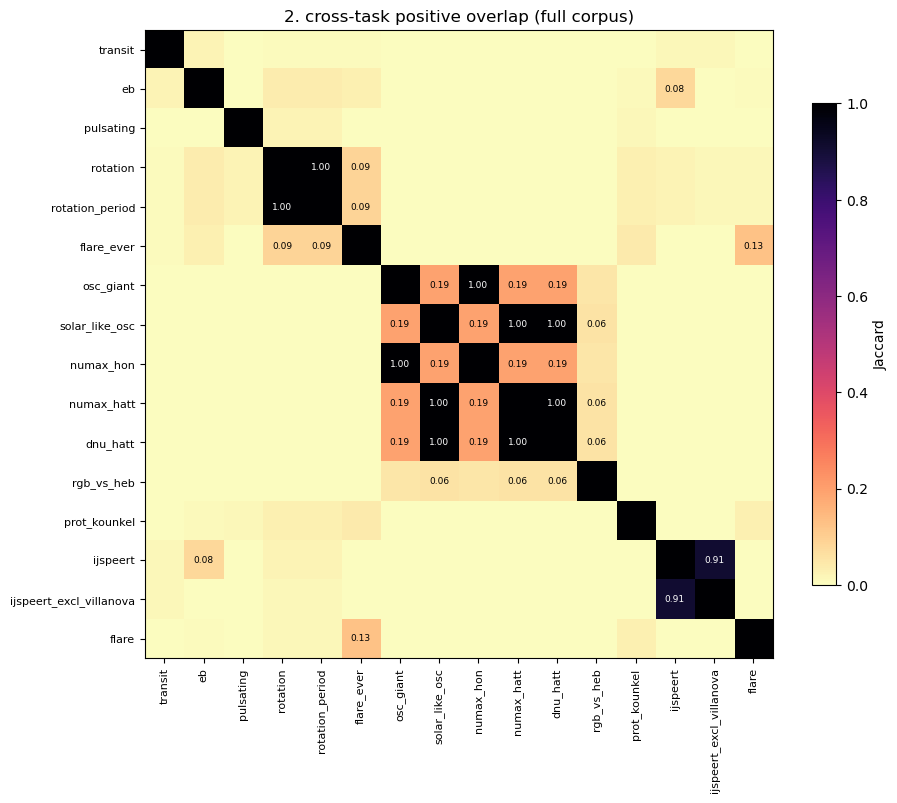

,task,max_jaccard,partner,n_shared
3,rotation,1.000,rotation_period,25369
7,solar_like_osc,1.000,numax_hatt,2757
6,osc_giant,1.000,numax_hon,8789
4,rotation_period,1.000,rotation,25369
9,numax_hatt,1.000,solar_like_osc,2757
10,dnu_hatt,1.000,solar_like_osc,2757
8,numax_hon,1.000,osc_giant,8789
13,ijspeert,0.909,ijspeert_excl_villanova,7501
14,ijspeert_excl_villanova,0.909,ijspeert,7501
15,flare,0.126,flare_ever,392


In [10]:
tasks = [r["task"] for r in REGISTRY]
J = pd.DataFrame(np.eye(len(tasks)), index=tasks, columns=tasks)
INTER = pd.DataFrame(0, index=tasks, columns=tasks, dtype=int)
sets = {r["task"]: set(np.asarray(r["positives"], dtype="int64").tolist()) for r in REGISTRY}
for i, a in enumerate(tasks):
    for b in tasks[i + 1:]:
        inter = len(sets[a] & sets[b])
        union = len(sets[a] | sets[b])
        J.loc[a, b] = J.loc[b, a] = inter / union if union else 0.0
        INTER.loc[a, b] = INTER.loc[b, a] = inter

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(J.values, cmap="magma_r", vmin=0, vmax=1)
ax.set_xticks(range(len(tasks))); ax.set_xticklabels(tasks, rotation=90, fontsize=8)
ax.set_yticks(range(len(tasks))); ax.set_yticklabels(tasks, fontsize=8)
for i in range(len(tasks)):
    for k in range(len(tasks)):
        v = J.values[i, k]
        if i != k and v >= 0.05:
            ax.text(k, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if v > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.75, label="Jaccard")
ax.set_title("2. cross-task positive overlap (full corpus)")
plt.tight_layout(); plt.savefig(FIGS / "2_overlap.png", dpi=120, bbox_inches="tight"); plt.show()

off = J.where(~np.eye(len(tasks), dtype=bool))
OVERLAP = pd.DataFrame({
    "task": tasks,
    "max_jaccard": off.max(axis=1).values,
    "partner": off.idxmax(axis=1).values,
    "n_shared": [int(INTER.loc[t, off.loc[t].idxmax()]) for t in tasks],
})
display(OVERLAP.sort_values("max_jaccard", ascending=False).round(3))

## 3. Negative-class construction

The rotation confound is a *negative*-side bug, and it is structural rather than accidental:

```python
# src/swm/data/subset.py:90
is_quiet = labels[all_label_cols].sum(axis=1) == 0   # matched in NO catalog
```

Both eval pools draw from that same rule. So no task's negatives are "not-this-task" — they are
"not-anything". `osc_giant` positives are red giants and its negatives are random quiet stars,
mostly dwarfs; the probe can score well by being a stellar-type classifier. `rgb_vs_heb` is the
only entry in the registry with genuinely matched negatives, and it is also the task where trained
barely beats untrained (0.81 vs 0.76). That may be the whole story, or a coincidence.

Three parts, in increasing strength: **declared** (what the rule says), **measured** (how often the
quiet pool actually shows the task's own signal), **counterfactual** (how big a matched pool would be).

In [11]:
# --- 3a declared -----------------------------------------------------------
DECLARED = pd.DataFrame([
    {"task": r["task"], "kind": r["kind"], "positive_rule": r["positive_rule"],
     "negative_rule": r["negative_rule"]}
    for r in REGISTRY
])
with pd.option_context("display.max_colwidth", 90):
    display(DECLARED)

# how many quiet stars carry each label anyway (they cannot, by construction -- this
# verifies the rule rather than discovering anything, and pins the rotation confound)
qrows = []
for r in REGISTRY:
    pos = set(np.asarray(r["positives"], dtype="int64").tolist())
    qrows.append({"task": r["task"],
                  "quiet_v1_positive": len(pos & set(QUIET_V1.tolist())),
                  "quiet_new_positive": len(pos & set(QUIET_NEW.tolist())),
                  "corpus_rate": len(pos) / N_CORPUS})
QUIET_CHECK = pd.DataFrame(qrows)
QUIET_CHECK["expected_if_random_v1"] = QUIET_CHECK.corpus_rate * len(QUIET_V1)
display(QUIET_CHECK.round(3))
print("Any row with quiet_*_positive = 0 and expected_if_random >> 0 is a task whose negative "
      "class was constructed by excluding its own positives.")

,task,kind,positive_rule,negative_rule
0,transit,detection,"tfopwg_disp in {CP,KP,PC,APC} (ADR-0009 whitelist)",quiet pool (matched in NO catalog)
1,eb,detection,"Villanova/Prsa+2022 only, strictly 0/1 (ADR-0007)",quiet pool
2,pulsating,detection,"Gao+2025 only, no negative mask",quiet pool
3,rotation,detection,TARS rotation detection,"quiet pool -- CONFOUNDED: quiet excludes rotation, so 0/10,000 negatives"
4,rotation_period,regression,"rotation==1 and rotation_period present (P<=5 d scope, ADR-0004)",n/a (regression on positives only)
5,flare_ever,detection,flatwrm2 >=1 flare in any sector,quiet pool
6,osc_giant,detection,Hon+2021 oscillation detection in a red giant,"quiet pool -- positives are giants, negatives are random quiet stars (unmatched)"
7,solar_like_osc,detection,Hatt+2023 solar-like oscillator,quiet pool (unmatched)
8,numax_hon,regression,Hon+2021 numax present,n/a (regression)
9,numax_hatt,regression,Hatt+2023 numax present,n/a (regression)


,task,quiet_v1_positive,quiet_new_positive,corpus_rate,expected_if_random_v1
0,transit,0,0,0.005,45.333
1,eb,0,0,0.010,98.835
2,pulsating,0,0,0.010,104.654
3,rotation,0,0,0.130,1295.110
4,rotation_period,0,0,0.130,1295.110
5,flare_ever,0,0,0.016,159.228
6,osc_giant,804,0,0.045,448.686
7,solar_like_osc,255,0,0.014,140.747
8,numax_hon,804,0,0.045,448.686
9,numax_hatt,255,0,0.014,140.747


Any row with quiet_*_positive = 0 and expected_if_random >> 0 is a task whose negative class was constructed by excluding its own positives.


,task,family,threshold,n_neg,frac_neg_with_signal,n_pos,frac_pos_with_signal
5,flare_ever,transient,5.0,300,0.253,300,0.223
15,flare,transient,5.0,300,0.213,300,0.303
1,eb,eclipse_like,5.0,300,0.063,300,0.460
0,transit,eclipse_like,5.0,300,0.060,300,0.400
14,ijspeert_excl_villanova,eclipse_like,5.0,300,0.043,300,0.463
13,ijspeert,eclipse_like,5.0,300,0.040,300,0.543
2,pulsating,coherent_periodic,2.0,0,NaN,294,0.993
3,rotation,coherent_periodic,2.0,0,NaN,228,0.912
4,rotation_period,coherent_periodic,2.0,0,NaN,235,0.915
6,osc_giant,stochastic_power_excess,2.0,0,NaN,300,0.997


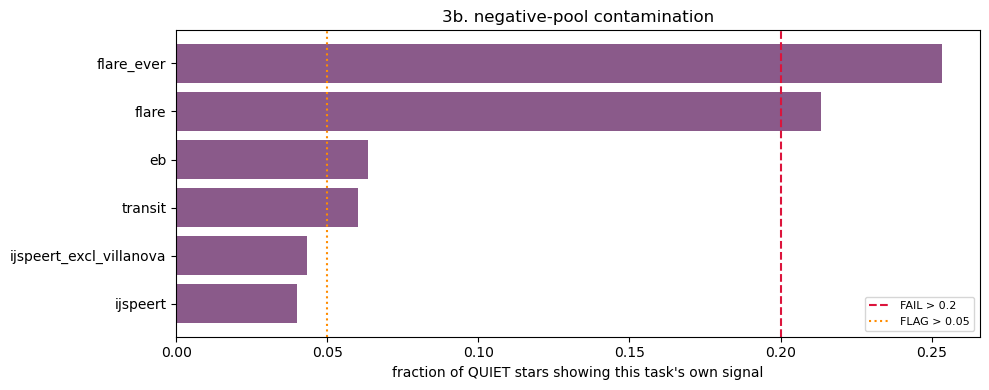

In [12]:
# --- 3b measured: run each task's own signal test on the quiet sample -------
gen = GATES["generic"]["negative_pool_contamination"]

def _signal_threshold(fam: str) -> tuple[str, float]:
    f = GATES["families"][fam]["signal_snr"]
    if fam == "eclipse_like":
        return "fold_snr", f["snr_threshold"]
    if fam == "coherent_periodic":
        return "neg_log10_ls_fap", -np.log10(f["fap_threshold"])
    if fam == "stochastic_power_excess":
        return "psd_excess", f["excess_threshold"]
    return "max_sigma_excursion", f["sigma_threshold"]


rows = []
for task, d in MEAS.items():
    if not len(d) or "signal" not in d:
        continue
    fam = REG[task]["family"]
    _, thr = _signal_threshold(fam)
    neg = d[~d.is_pos].signal.dropna()
    pos = d[d.is_pos].signal.dropna()
    rows.append({"task": task, "family": fam, "threshold": thr,
                 "n_neg": len(neg), "frac_neg_with_signal": float((neg >= thr).mean()) if len(neg) else np.nan,
                 "n_pos": len(pos), "frac_pos_with_signal": float((pos >= thr).mean()) if len(pos) else np.nan})
CONTAM = pd.DataFrame(rows)
display(CONTAM.round(3).sort_values("frac_neg_with_signal", ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
c = CONTAM.dropna(subset=["frac_neg_with_signal"]).sort_values("frac_neg_with_signal")
ax.barh(c.task, c.frac_neg_with_signal, color="#8a5a8a")
ax.axvline(gen["fail_above"], color="crimson", ls="--", label=f"FAIL > {gen['fail_above']}")
ax.axvline(gen["flag_above"], color="darkorange", ls=":", label=f"FLAG > {gen['flag_above']}")
ax.set_xlabel("fraction of QUIET stars showing this task's own signal")
ax.set_title("3b. negative-pool contamination"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "3b_negative_contamination.png", dpi=120, bbox_inches="tight"); plt.show()

In [13]:
# --- 3c counterfactual: how big would a MATCHED negative pool be? ----------
# For each detection task, the matched pool is drawn from the same parent
# population as the positives rather than from "quiet". Report-only -- this
# sizes the fix, it does not apply it.
MATCHED_PARENT = {
    "osc_giant": ("Hon+2021 targets that are NOT flagged oscillating",
                  set(HON.TIC.astype("int64")) - set(_pos(NEW_TASK, "osc_giant").tolist())),
    "solar_like_osc": ("Hatt+2023 targets without a solar-like detection",
                       set(HATT.TIC.astype("int64")) - set(_pos(NEW_TASK, "solar_like_osc").tolist())),
    "rgb_vs_heb": ("Sreenivas+2025 RGB stars (already matched)",
                   set(NEW_TASK.loc[NEW_TASK.rgb_vs_heb == 0, "tic_id"].astype("int64"))),
    "eb": ("stars with a rotation OR pulsating label but no EB label",
           (set(_pos(LABELS_V1, "rotation").tolist()) | set(_pos(LABELS_V1, "pulsating").tolist()))
           - set(_pos(LABELS_V1, "eb").tolist())),
    "transit": ("stars in any variability catalog but not transit",
                (set(_pos(LABELS_V1, "rotation").tolist()) | set(_pos(LABELS_V1, "eb").tolist())
                 | set(_pos(LABELS_V1, "pulsating").tolist())) - set(_pos(LABELS_V1, "transit").tolist())),
    "pulsating": ("stars in any variability catalog but not pulsating",
                  (set(_pos(LABELS_V1, "rotation").tolist()) | set(_pos(LABELS_V1, "eb").tolist()))
                  - set(_pos(LABELS_V1, "pulsating").tolist())),
    "flare_ever": ("stars in any variability catalog but no flare",
                   (set(_pos(LABELS_V1, "rotation").tolist()) | set(_pos(LABELS_V1, "eb").tolist())
                    | set(_pos(LABELS_V1, "pulsating").tolist())) - set(_pos(LABELS_V1, "flare_ever").tolist())),
    "ijspeert": ("Villanova EBs not in Ijspeert (same phenomenon, other catalog)",
                 set(_pos(LABELS_V1, "eb").tolist()) - set(IJ_TICS.tolist())),
}
hw = set(HAS_WINDOWS.tolist())
rows = []
for r in REGISTRY:
    if r["kind"] not in ("detection", "contrastive"):
        continue
    desc, pool = MATCHED_PARENT.get(r["task"], ("(no obvious matched parent population)", set()))
    rows.append({"task": r["task"], "matched_pool_definition": desc,
                 "n_matched": len(pool), "n_matched_with_windows": len(pool & hw),
                 "n_quiet_used_today": len(QUIET_ALL)})
COUNTERFACTUAL = pd.DataFrame(rows)
display(COUNTERFACTUAL)
print("A matched pool an order of magnitude smaller than the 10k quiet draw means the fair version "
      "of that probe is also a much lower-powered one -- that trade-off is the finding, not a blocker.")

,task,matched_pool_definition,n_matched,n_matched_with_windows,n_quiet_used_today
0,transit,stars in any variability catalog but not transit,27584,16446,19014
1,eb,stars with a rotation OR pulsating label but n...,25869,15364,19014
2,pulsating,stars in any variability catalog but not pulsa...,25755,15198,19014
3,rotation,(no obvious matched parent population),0,0,19014
4,flare_ever,stars in any variability catalog but no flare,25489,15107,19014
5,osc_giant,Hon+2021 targets that are NOT flagged oscillating,149716,190,19014
6,solar_like_osc,Hatt+2023 targets without a solar-like detection,1420,99,19014
7,rgb_vs_heb,Sreenivas+2025 RGB stars (already matched),365,365,19014
8,ijspeert,Villanova EBs not in Ijspeert (same phenomenon...,1183,840,19014
9,ijspeert_excl_villanova,(no obvious matched parent population),0,0,19014


A matched pool an order of magnitude smaller than the 10k quiet draw means the fair version of that probe is also a much lower-powered one -- that trade-off is the finding, not a blocker.


## 4. Target redundancy

Two regression targets linked by a known deterministic law let a probe score well on one purely by
predicting the other. The concrete case: **Δν ∝ ν<sub>max</sub><sup>0.75</sup>**.

`dnu_hatt` scores R² = 0.83 in the exp05 scorecard, while its median value (5.31 µHz) sits *below*
the single-window frequency resolution (8.14 µHz). The probe cannot be resolving the frequency comb,
so the scaling relation is the only available route. That is not fraud — but it means `dnu_hatt` and
`numax_hatt` are close to one measurement reported twice, and should not be counted as two
independent probe wins.

,numax_hon,numax_hatt,dnu_hatt,prot_kounkel,rotation_period
numax_hon,1.000,0.981,0.980,0.836,-0.064
numax_hatt,0.981,1.000,0.993,NaN,0.077
dnu_hatt,0.980,0.993,1.000,NaN,0.131
prot_kounkel,0.836,NaN,NaN,1.000,0.907
rotation_period,-0.064,0.077,0.131,0.907,1.000


,target,predictor,n,raw_abs_r,fitted_exponent,resid_scatter_dex,frac_variance_explained_by_law
0,dnu_hatt,numax_hatt,2757,0.993,0.79,0.0406,0.9861


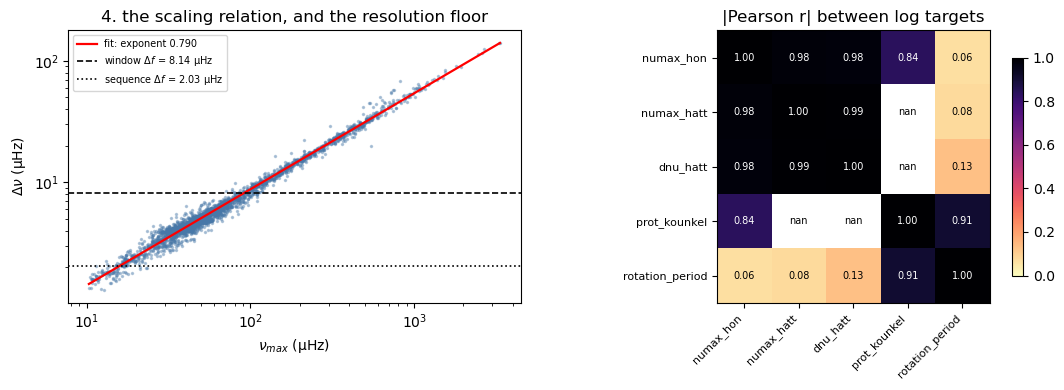

70.5% of dnu_hatt values are below the single-window resolution; 3.0% are below the sequence resolution.


In [14]:
reg_targets = {"numax_hon": NEW_TASK.set_index("tic_id").numax_hon,
               "numax_hatt": NEW_TASK.set_index("tic_id").numax_hatt,
               "dnu_hatt": NEW_TASK.set_index("tic_id").dnu_hatt,
               "prot_kounkel": NEW_TASK.set_index("tic_id").prot_kounkel,
               "rotation_period": LABELS_V1.set_index("tic_id").rotation_period}
T = pd.DataFrame(reg_targets)
CORR = T.apply(np.log10).corr(method="pearson")
display(CORR.round(3))

rows = []
for rel in GATES["generic"]["target_redundancy"]["scaling_relations"]:
    a, b = rel["target"], rel["predictor"]
    m = T[[a, b]].dropna()
    if len(m) < 10:
        continue
    # fit log(dnu) = c + 0.75*log(numax), then correlate the RESIDUAL with the predictor
    x, y = np.log10(m[b].values), np.log10(m[a].values)
    coef = np.polyfit(x, y, 1)
    resid = y - np.polyval(coef, x)
    rows.append({"target": a, "predictor": b, "n": len(m),
                 "raw_abs_r": float(abs(np.corrcoef(x, y)[0, 1])),
                 "fitted_exponent": float(coef[0]),
                 "resid_scatter_dex": float(np.std(resid)),
                 "frac_variance_explained_by_law": float(1 - np.var(resid) / np.var(y))})
REDUNDANCY = pd.DataFrame(rows)
display(REDUNDANCY.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
m = T[["dnu_hatt", "numax_hatt"]].dropna()
ax[0].loglog(m.numax_hatt, m.dnu_hatt, ".", ms=3, alpha=0.35, color="#4878a8")
xs = np.logspace(np.log10(m.numax_hatt.min()), np.log10(m.numax_hatt.max()), 50)
ax[0].loglog(xs, 10 ** np.polyval(np.polyfit(np.log10(m.numax_hatt), np.log10(m.dnu_hatt), 1), np.log10(xs)),
             "r-", lw=1.6, label=f"fit: exponent {REDUNDANCY.fitted_exponent.iloc[0]:.3f}")
ax[0].axhline(WINDOW_DF_UHZ, color="k", ls="--", lw=1.2, label=f"window $\\Delta f$ = {WINDOW_DF_UHZ:.2f} µHz")
ax[0].axhline(SEQ_DF_UHZ, color="k", ls=":", lw=1.2, label=f"sequence $\\Delta f$ = {SEQ_DF_UHZ:.2f} µHz")
ax[0].set_xlabel(r"$\nu_{max}$ (µHz)"); ax[0].set_ylabel(r"$\Delta\nu$ (µHz)")
ax[0].set_title("4. the scaling relation, and the resolution floor"); ax[0].legend(fontsize=7)

im = ax[1].imshow(CORR.abs().values, cmap="magma_r", vmin=0, vmax=1)
ax[1].set_xticks(range(len(CORR))); ax[1].set_xticklabels(CORR.columns, rotation=45, ha="right", fontsize=8)
ax[1].set_yticks(range(len(CORR))); ax[1].set_yticklabels(CORR.index, fontsize=8)
for i in range(len(CORR)):
    for k in range(len(CORR)):
        ax[1].text(k, i, f"{abs(CORR.values[i, k]):.2f}", ha="center", va="center", fontsize=7,
                   color="white" if abs(CORR.values[i, k]) > 0.5 else "black")
ax[1].set_title("|Pearson r| between log targets")
plt.colorbar(im, ax=ax[1], shrink=0.8)
plt.tight_layout(); plt.savefig(FIGS / "4_redundancy.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"{(m.dnu_hatt < WINDOW_DF_UHZ).mean():.1%} of dnu_hatt values are below the single-window "
      f"resolution; {(m.dnu_hatt < SEQ_DF_UHZ).mean():.1%} are below the sequence resolution.")

## 5. Resolvability

Whether the catalogued quantity is *measurable at all* in what the encoder sees — independent of
labels being correct, and independent of the model being any good.

* **coherent-periodic** — a cycle longer than the 34.13 h window is never seen whole.
  `prot_kounkel`'s median period is 1.58 d = 38 h, so the median positive already fails.
* **stochastic** — a frequency below ~3 resolution elements cannot be located in the periodogram.

Containment is a property of the **geometry**, not of the label, so it is reported as a curve over
the window sizes exp06 is currently sweeping rather than as one number at 1024.

,task,n,median_P_h,w256,w512,w1024,w2048,w4096,seq
0,pulsating,300,1.196,0.940,0.947,0.947,0.953,0.980,0.980
1,rotation,300,74.164,0.110,0.223,0.320,0.477,0.643,0.643
2,rotation_period,300,68.782,0.097,0.213,0.330,0.497,0.703,0.703
3,prot_kounkel,300,37.027,0.163,0.280,0.470,0.680,0.860,0.860


,task,n,median_freq_uhz,frac_ge_3df_window,frac_ge_3df_sequence
0,osc_giant,300,36.400,0.850,1.000
1,solar_like_osc,300,54.025,0.907,1.000
2,numax_hon,300,34.300,0.863,1.000
3,numax_hatt,300,53.105,0.907,1.000
4,dnu_hatt,300,5.695,0.083,0.453
5,rgb_vs_heb,300,25.945,0.510,0.820


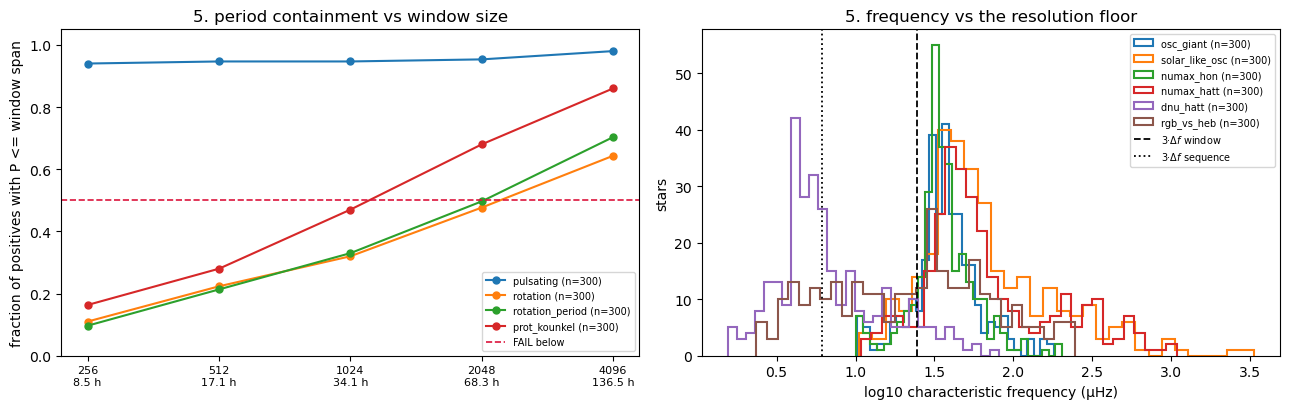

In [15]:
GRID = GATES["geometry"]["containment_window_grid"]
span_h = {w: w * CAD_S / 3600.0 for w in GRID}

rows = []
for r in REGISTRY:
    if r["family"] != "coherent_periodic":
        continue
    d = MEAS.get(r["task"])
    if d is None or not len(d):
        continue
    p = d.loc[d.is_pos, "period_d"].dropna() * 24.0  # hours
    if not len(p):
        continue
    row = {"task": r["task"], "n": len(p), "median_P_h": float(p.median())}
    for w in GRID:
        row[f"w{w}"] = float((p <= span_h[w]).mean())
    row["seq"] = float((p <= SEQ_SPAN_D * 24).mean())
    rows.append(row)
CONTAINMENT = pd.DataFrame(rows)
display(CONTAINMENT.round(3))

rows = []
for r in REGISTRY:
    if r["family"] != "stochastic_power_excess":
        continue
    d = MEAS.get(r["task"])
    if d is None or not len(d):
        continue
    fr = d.loc[d.is_pos, "freq_uhz"].dropna()
    if not len(fr):
        continue
    n = GATES["families"]["stochastic_power_excess"]["frequency_resolvability"]["n_delta_f"]
    rows.append({"task": r["task"], "n": len(fr), "median_freq_uhz": float(fr.median()),
                 f"frac_ge_{n}df_window": float((fr >= n * WINDOW_DF_UHZ).mean()),
                 f"frac_ge_{n}df_sequence": float((fr >= n * SEQ_DF_UHZ).mean())})
FREQ_RES = pd.DataFrame(rows)
display(FREQ_RES.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for _, r in CONTAINMENT.iterrows():
    ax[0].plot(range(len(GRID)), [r[f"w{w}"] for w in GRID], "o-", ms=5, label=f"{r['task']} (n={int(r['n'])})")
ax[0].axhline(GATES["families"]["coherent_periodic"]["period_containment"]["fail_below"],
              color="crimson", ls="--", lw=1.2, label="FAIL below")
ax[0].set_xticks(range(len(GRID)))
ax[0].set_xticklabels([f"{w}\n{span_h[w]:.1f} h" for w in GRID], fontsize=8)
ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("fraction of positives with P <= window span")
ax[0].set_title("5. period containment vs window size"); ax[0].legend(fontsize=7)

for r in REGISTRY:
    if r["family"] != "stochastic_power_excess":
        continue
    d = MEAS.get(r["task"])
    if d is None or not len(d):
        continue
    fr = d.loc[d.is_pos, "freq_uhz"].dropna()
    if len(fr):
        ax[1].hist(np.log10(fr), bins=30, histtype="step", lw=1.5, label=f"{r['task']} (n={len(fr)})")
ax[1].axvline(np.log10(3 * WINDOW_DF_UHZ), color="k", ls="--", lw=1.3, label=f"3·$\\Delta f$ window")
ax[1].axvline(np.log10(3 * SEQ_DF_UHZ), color="k", ls=":", lw=1.3, label=f"3·$\\Delta f$ sequence")
ax[1].set_xlabel("log10 characteristic frequency (µHz)"); ax[1].set_ylabel("stars")
ax[1].set_title("5. frequency vs the resolution floor"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGS / "5_resolvability.png", dpi=120, bbox_inches="tight"); plt.show()

## 6. Event coverage

For localized-event tasks: does a catalogued event land on a cadence we actually packed?

The gate is on the **ratio to what the ephemeris predicts**, not on absolute coverage. Absolute
coverage is largely set by orbital geometry — a 10-day planet with a 3-hour transit spends ~1.3% of
its time in transit and there is nothing wrong with that. The ratio isolates the part that *is* a
defect: events that should have been observable in our packed data and are not.

**The denominator must be per-sector, not global.** An early version of this section counted every
event in `[t.min(), t.max()]`, which for a star observed in sectors 14 and 60 includes years of
sectors we never downloaded — the ratio then collapses toward zero and is measuring TESS's survey
cadence, not our pipeline. The gate reads the per-sector version (events inside sectors we actually
hold); the global version is reported beside it as `baseline_frac`, which answers the different and
also-useful question "how much of this star's full baseline do we have?".

This reframes the existing transit number. 8.3% median absolute coverage is either a pass or a much
worse failure than it sounds, depending on a denominator that was never computed.

,task,n_with_ephemeris,t0_source,median_cov_ratio,ci_lo,ci_hi,median_n_exp_events,median_n_obs_events,median_sectors_held,median_baseline_frac,frac_stars_zero_events,note
0,transit,268,toi,0.965,0.913,1.0,4.0,3.0,2.0,0.063,0.011,
1,eb,287,fold,0.963,0.926,1.0,10.0,8.0,2.0,0.193,0.000,
2,ijspeert,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no ephemeris available
3,ijspeert_excl_villanova,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no ephemeris available


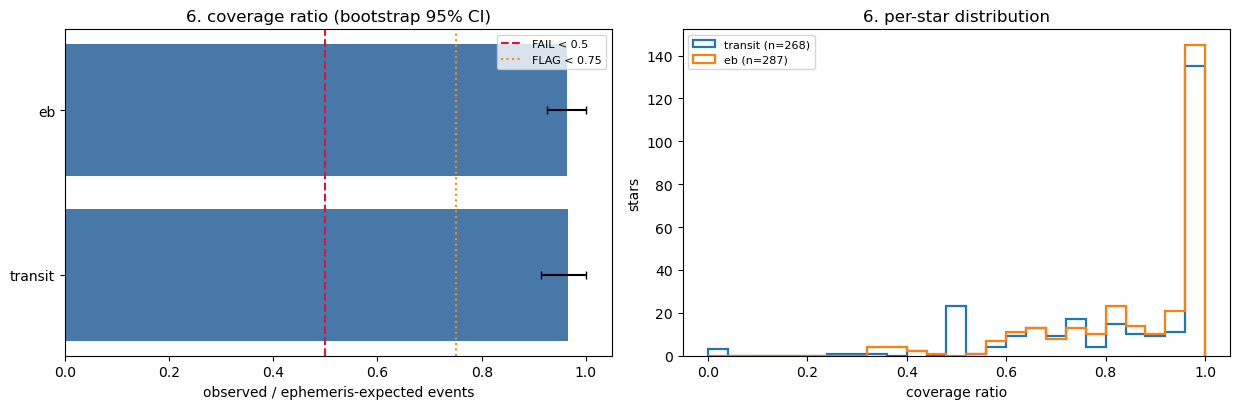

In [16]:
g = GATES["families"]["eclipse_like"]["coverage_ratio"]
rows = []
for r in REGISTRY:
    if r["family"] != "eclipse_like":
        continue
    d = MEAS.get(r["task"])
    if d is None or not len(d) or "cov_ratio" not in d:
        rows.append({"task": r["task"], "n_with_ephemeris": 0, "note": "no ephemeris available"})
        continue
    dd = d[d.is_pos].dropna(subset=["cov_ratio"])
    if not len(dd):
        rows.append({"task": r["task"], "n_with_ephemeris": 0, "note": "no ephemeris available"})
        continue
    boot = [np.median(dd.cov_ratio.sample(len(dd), replace=True)) for _ in range(GATES["sampling"]["bootstrap_n"])]
    rows.append({
        "task": r["task"], "n_with_ephemeris": len(dd),
        "t0_source": dd.t0_source.mode().iloc[0] if "t0_source" in dd else "?",
        "median_cov_ratio": float(dd.cov_ratio.median()),
        "ci_lo": float(np.percentile(boot, 2.5)), "ci_hi": float(np.percentile(boot, 97.5)),
        "median_n_exp_events": float(dd.n_exp_events.median()),
        "median_n_obs_events": float(dd.n_obs_events.median()),
        "median_sectors_held": float(dd.n_sectors_held.median()) if "n_sectors_held" in dd else np.nan,
        "median_baseline_frac": float(dd.baseline_frac.median()) if "baseline_frac" in dd else np.nan,
        "frac_stars_zero_events": float((dd.n_obs_events == 0).mean()),
        "note": "",
    })
COVERAGE = pd.DataFrame(rows)
if "median_cov_ratio" not in COVERAGE:
    COVERAGE["median_cov_ratio"] = np.nan
    for c in ("ci_lo", "ci_hi", "t0_source", "frac_stars_zero_events",
              "median_baseline_frac", "median_sectors_held"):
        COVERAGE[c] = np.nan
display(COVERAGE.round(3))

cc = COVERAGE.dropna(subset=["median_cov_ratio"])
if len(cc):
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
    ax[0].barh(cc.task, cc.median_cov_ratio,
               xerr=[cc.median_cov_ratio - cc.ci_lo, cc.ci_hi - cc.median_cov_ratio],
               color="#4878a8", capsize=3)
    ax[0].axvline(g["fail_below"], color="crimson", ls="--", label=f"FAIL < {g['fail_below']}")
    ax[0].axvline(g["flag_below"], color="darkorange", ls=":", label=f"FLAG < {g['flag_below']}")
    ax[0].set_xlim(0, 1.05); ax[0].set_xlabel("observed / ephemeris-expected events")
    ax[0].set_title("6. coverage ratio (bootstrap 95% CI)"); ax[0].legend(fontsize=8)
    for r in REGISTRY:
        if r["family"] != "eclipse_like":
            continue
        d = MEAS.get(r["task"])
        if d is None or "cov_ratio" not in d:
            continue
        v = d[d.is_pos].cov_ratio.dropna()
        if len(v):
            ax[1].hist(v, bins=np.linspace(0, 1, 26), histtype="step", lw=1.6, label=f"{r['task']} (n={len(v)})")
    ax[1].set_xlabel("coverage ratio"); ax[1].set_ylabel("stars"); ax[1].legend(fontsize=8)
    ax[1].set_title("6. per-star distribution")
    plt.tight_layout(); plt.savefig(FIGS / "6_coverage.png", dpi=120, bbox_inches="tight"); plt.show()

## 7. Signal presence

Catalogue membership is not evidence that the signal is in *our* data. This is what caught the
suspect Villanova EBs (corroborated median fold-SNR 128 vs suspect 3.8).

Each family gets its own test, and positives are always shown against the quiet sample run through
the *same* test — a positive distribution that overlaps the negative one is the finding, not the
absolute number.

,task,family,metric,metric_used,is_fallback,threshold,n_pos,median_pos,frac_pos_pass,ci_lo,ci_hi,n_neg,median_neg,frac_neg_pass
12,prot_kounkel,coherent_periodic,neg_log10_ls_fap,neg_log10_ls_fap,False,2.0,285,300.000,0.888,0.846,0.923,0,NaN,NaN
3,rotation,coherent_periodic,neg_log10_ls_fap,neg_log10_ls_fap,False,2.0,228,300.000,0.912,0.873,0.947,0,NaN,NaN
4,rotation_period,coherent_periodic,neg_log10_ls_fap,neg_log10_ls_fap,False,2.0,235,300.000,0.915,0.877,0.949,0,NaN,NaN
2,pulsating,coherent_periodic,neg_log10_ls_fap,neg_log10_ls_fap,False,2.0,294,300.000,0.993,0.983,1.000,0,NaN,NaN
0,transit,eclipse_like,fold_snr,fold_snr,False,5.0,300,4.247,0.400,0.343,0.453,300,3.669,0.060
1,eb,eclipse_like,fold_snr,fold_snr,False,5.0,300,4.037,0.460,0.403,0.517,300,3.703,0.063
14,ijspeert_excl_villanova,eclipse_like,fold_snr,max_sigma_dip_unfolded,True,5.0,300,4.577,0.463,0.407,0.523,300,3.663,0.043
13,ijspeert,eclipse_like,fold_snr,max_sigma_dip_unfolded,True,5.0,300,5.829,0.543,0.487,0.603,300,3.709,0.040
10,dnu_hatt,stochastic_power_excess,psd_excess,psd_excess,False,2.0,106,1.326,0.255,0.170,0.340,0,NaN,NaN
9,numax_hatt,stochastic_power_excess,psd_excess,psd_excess,False,2.0,300,12.436,0.873,0.837,0.907,0,NaN,NaN


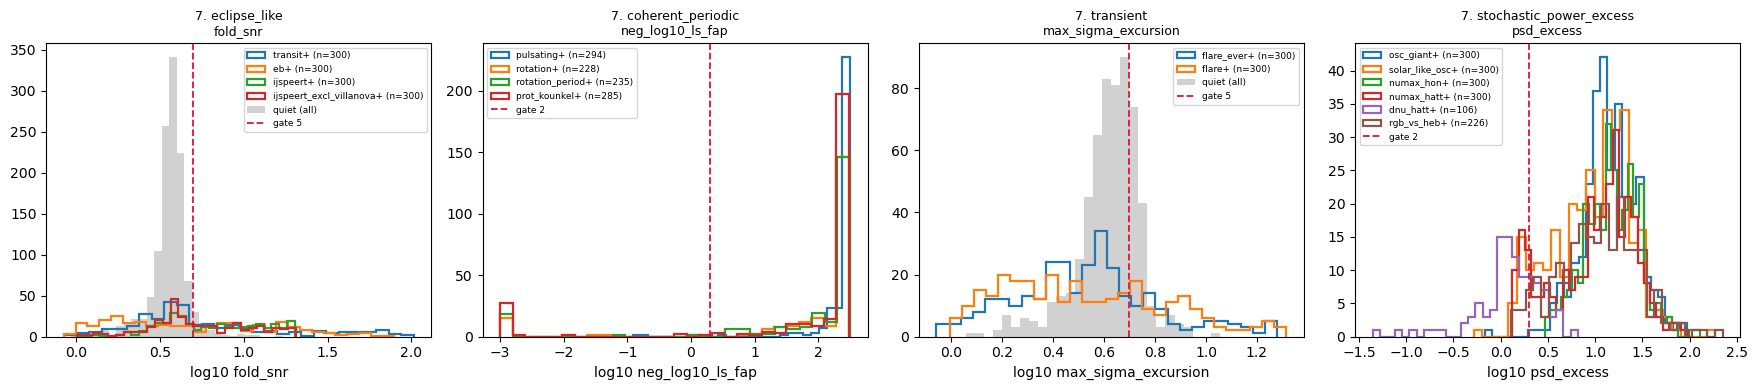

In [17]:
rows = []
for r in REGISTRY:
    task, fam = r["task"], r["family"]
    d = MEAS.get(task)
    if d is None or not len(d) or "signal" not in d:
        continue
    metric, thr = _signal_threshold(fam)
    pos = d.loc[d.is_pos, "signal"].dropna()
    neg = d.loc[~d.is_pos, "signal"].dropna()
    if not len(pos):
        continue
    used = d.loc[d.is_pos, "signal_metric"].mode()
    used = used.iloc[0] if len(used) else metric
    boot = [(pos.sample(len(pos), replace=True) >= thr).mean() for _ in range(GATES["sampling"]["bootstrap_n"])]
    rows.append({"task": task, "family": fam, "metric": metric, "metric_used": used,
                 "is_fallback": used.endswith("_unfolded"), "threshold": thr,
                 "n_pos": len(pos), "median_pos": float(pos.median()),
                 "frac_pos_pass": float((pos >= thr).mean()),
                 "ci_lo": float(np.percentile(boot, 2.5)), "ci_hi": float(np.percentile(boot, 97.5)),
                 "n_neg": len(neg), "median_neg": float(neg.median()) if len(neg) else np.nan,
                 "frac_neg_pass": float((neg >= thr).mean()) if len(neg) else np.nan})
SIGNAL = pd.DataFrame(rows)
display(SIGNAL.round(3).sort_values(["family", "frac_pos_pass"]))

fams = SIGNAL.family.unique()
fig, axes = plt.subplots(1, len(fams), figsize=(4.4 * len(fams), 4.0))
axes = np.atleast_1d(axes)
for ax, fam in zip(axes, fams):
    metric, thr = _signal_threshold(fam)
    for task in SIGNAL.loc[SIGNAL.family == fam, "task"]:
        d = MEAS[task]
        pos = d.loc[d.is_pos, "signal"].dropna()
        if len(pos):
            ax.hist(np.log10(np.clip(pos, 1e-3, None)), bins=28, histtype="step", lw=1.6,
                    label=f"{task}+ (n={len(pos)})")
    neg_all = pd.concat([MEAS[t].loc[~MEAS[t].is_pos, "signal"] for t in SIGNAL.loc[SIGNAL.family == fam, "task"]]).dropna()
    if len(neg_all):
        ax.hist(np.log10(np.clip(neg_all, 1e-3, None)), bins=28, histtype="stepfilled",
                color="0.6", alpha=0.45, label="quiet (all)")
    ax.axvline(np.log10(thr), color="crimson", ls="--", lw=1.3, label=f"gate {thr:g}")
    ax.set_title(f"7. {fam}\n{metric}", fontsize=9)
    ax.set_xlabel(f"log10 {metric}"); ax.legend(fontsize=6.5)
plt.tight_layout(); plt.savefig(FIGS / "7_signal.png", dpi=120, bbox_inches="tight"); plt.show()

## 8. Pipeline censoring

"Our own preprocessing removed the signal." The known instance: the `absmax=20` outlier guard is
**46× EB-enriched** — deep eclipses deleted as outliers, taking windowed EBs from 1,541 to 1,288.

Two mechanisms, very different evidential strength:

1. **absmax guard — exact.** 677 removed files with `tic_id, sector, seg_idx, flux_absmax`. Enrichment
   per task is a clean join. But 677 files means most tasks land in single digits, so this axis
   *flags*; it does not conclude.
2. **NaN Class-B/C discard — not measurable.** The per-class counts were never written and the source
   FITS are not retained, so the exact loss needs a MAST re-download. The **duty cycle** (packed
   cadences ÷ nominal span) bounds the combined loss instead, without attributing it.

,task,family,n_pos_with_windows,n_censored,censor_rate,enrichment,evidence
1,eb,eclipse_like,1276,86,0.067,28.929,usable
13,ijspeert,eclipse_like,1162,76,0.065,28.073,usable
14,ijspeert_excl_villanova,eclipse_like,726,36,0.050,21.284,usable
5,flare_ever,transient,2022,35,0.017,7.430,usable
15,flare,transient,392,6,0.015,6.570,usable
0,transit,eclipse_like,813,6,0.007,3.168,usable
4,rotation_period,coherent_periodic,14927,81,0.005,2.329,usable
3,rotation,coherent_periodic,14927,81,0.005,2.329,usable
12,prot_kounkel,coherent_periodic,1061,4,0.004,1.618,too few (flag only)
2,pulsating,coherent_periodic,1442,1,0.001,0.298,too few (flag only)


base censor rate over all windowed stars: 0.00233  (394 stars in the manifest)


,count_neg,count_pos,median_neg,median_pos,duty_pos_minus_neg
task,,,,,
numax_hatt,300,300,0.603,0.049,-0.554
dnu_hatt,300,300,0.597,0.049,-0.548
solar_like_osc,300,300,0.597,0.048,-0.548
prot_kounkel,300,300,0.597,0.061,-0.536
numax_hon,300,300,0.595,0.066,-0.529
transit,300,300,0.565,0.047,-0.517
osc_giant,300,300,0.600,0.103,-0.497
ijspeert,300,300,0.585,0.101,-0.484
rgb_vs_heb,300,300,0.600,0.137,-0.463


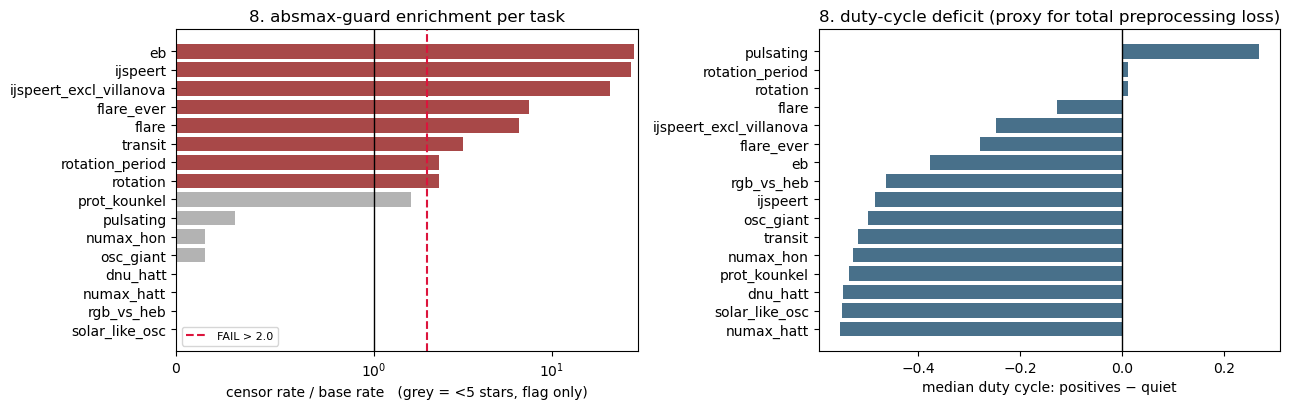

In [18]:
gc_ = GATES["families"]["eclipse_like"]["censoring"]
cens_tics = set(OUTLIERS.tic_id.astype("int64").tolist())
base_rate = len(cens_tics & set(HAS_WINDOWS.tolist())) / len(HAS_WINDOWS)

rows = []
for r in REGISTRY:
    pos = set(np.asarray(r["positives"], dtype="int64").tolist()) & set(HAS_WINDOWS.tolist())
    if not pos:
        continue
    hit = len(pos & cens_tics)
    rate = hit / len(pos)
    rows.append({"task": r["task"], "family": r["family"], "n_pos_with_windows": len(pos),
                 "n_censored": hit, "censor_rate": rate,
                 "enrichment": rate / base_rate if base_rate > 0 else np.nan})
CENSOR = pd.DataFrame(rows).sort_values("enrichment", ascending=False)
CENSOR["evidence"] = np.where(CENSOR.n_censored >= 5, "usable", "too few (flag only)")
display(CENSOR.round(3))
print(f"base censor rate over all windowed stars: {base_rate:.5f}  ({len(cens_tics):,} stars in the manifest)")

DUTY = (MEASURED.groupby(["task", "is_pos"])["duty_cycle"]
        .agg(["count", "median"]).unstack("is_pos"))
DUTY.columns = [f"{a}_{'pos' if b else 'neg'}" for a, b in DUTY.columns]
DUTY["duty_pos_minus_neg"] = DUTY.get("median_pos") - DUTY.get("median_neg")
display(DUTY.round(3).sort_values("duty_pos_minus_neg"))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
c = CENSOR.sort_values("enrichment")
cols = np.where(c.n_censored >= 5, "#a84848", "0.7")
ax[0].barh(c.task, c.enrichment, color=cols)
ax[0].axvline(1.0, color="k", lw=1)
ax[0].axvline(gc_["fail_above"], color="crimson", ls="--", label=f"FAIL > {gc_['fail_above']}")
ax[0].set_xscale("symlog", linthresh=1)
ax[0].set_xlabel("censor rate / base rate   (grey = <5 stars, flag only)")
ax[0].set_title("8. absmax-guard enrichment per task"); ax[0].legend(fontsize=8)

d = DUTY.dropna(subset=["duty_pos_minus_neg"]).sort_values("duty_pos_minus_neg")
ax[1].barh(d.index, d.duty_pos_minus_neg, color="#48708a")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("median duty cycle: positives − quiet")
ax[1].set_title("8. duty-cycle deficit (proxy for total preprocessing loss)")
plt.tight_layout(); plt.savefig(FIGS / "8_censoring.png", dpi=120, bbox_inches="tight"); plt.show()

## 9. Gallery — what a label actually looks like

One row per task: a random positive with windows shaded, a zoom or fold, and the
family-appropriate diagnostic. **A fresh star is drawn on every re-run** — the seeded line is
present but commented out, so replication is opt-in.

Read these against §7. A task whose positives look indistinguishable from noise here is a task
whose probe score is measuring something other than the labelled phenomenon.

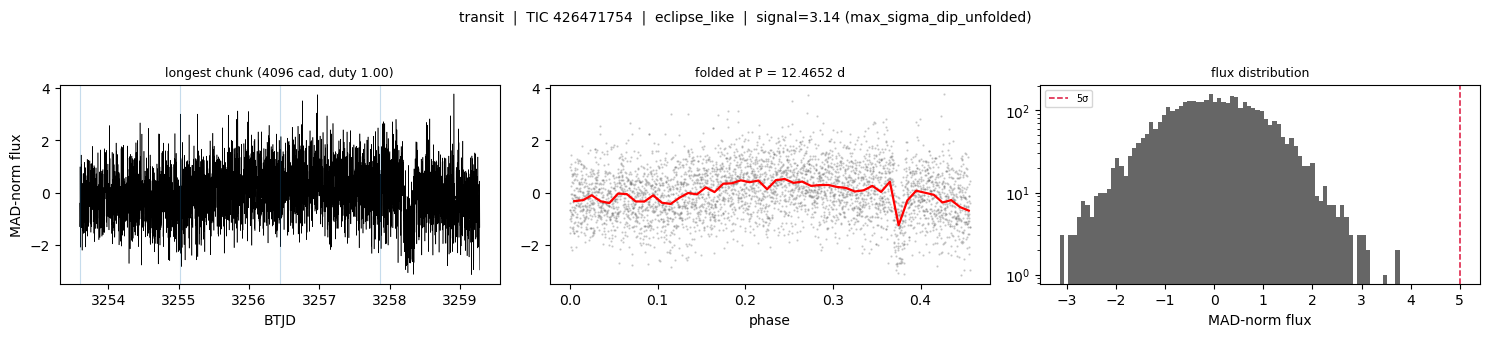

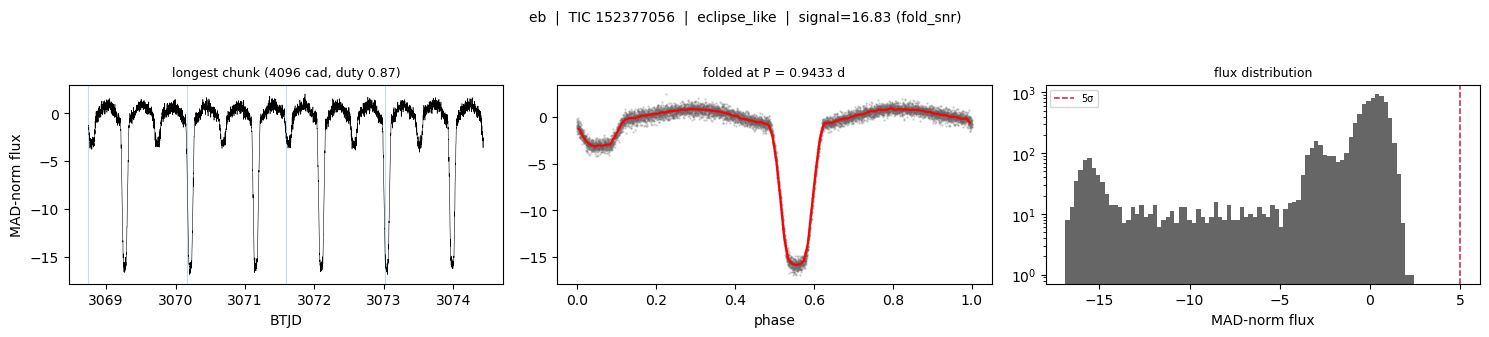

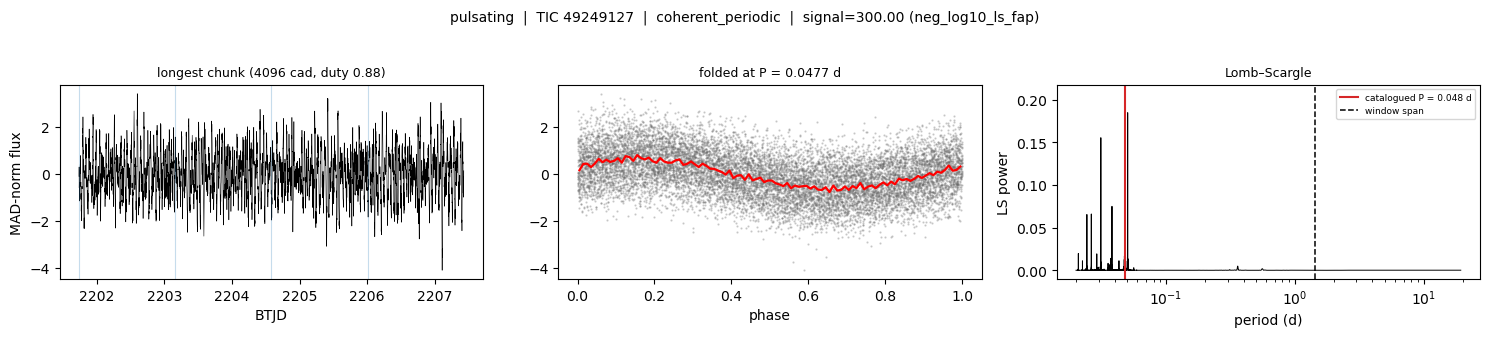

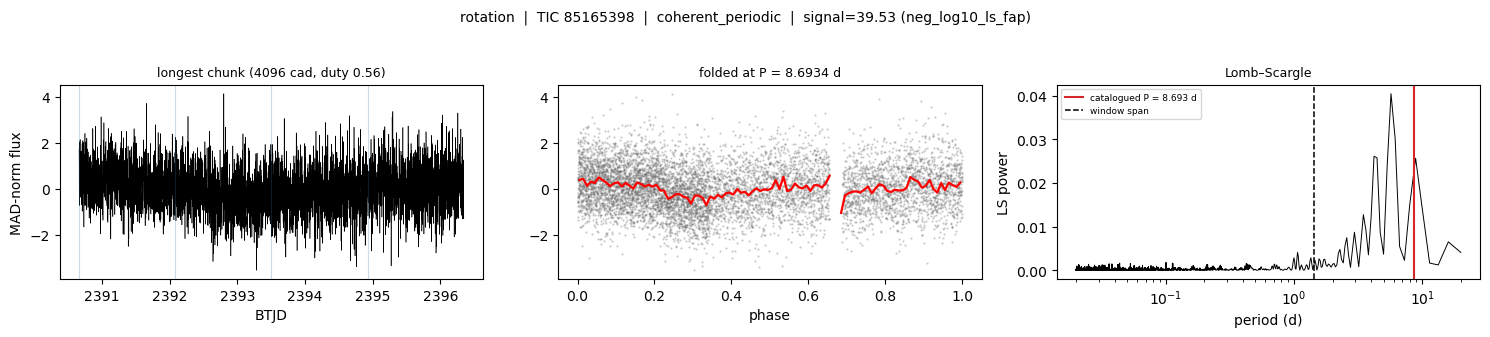

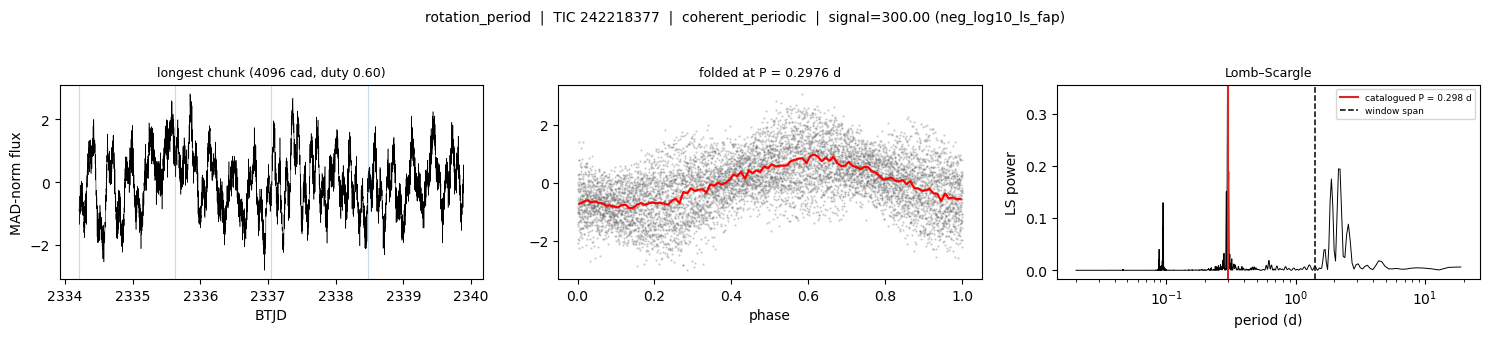

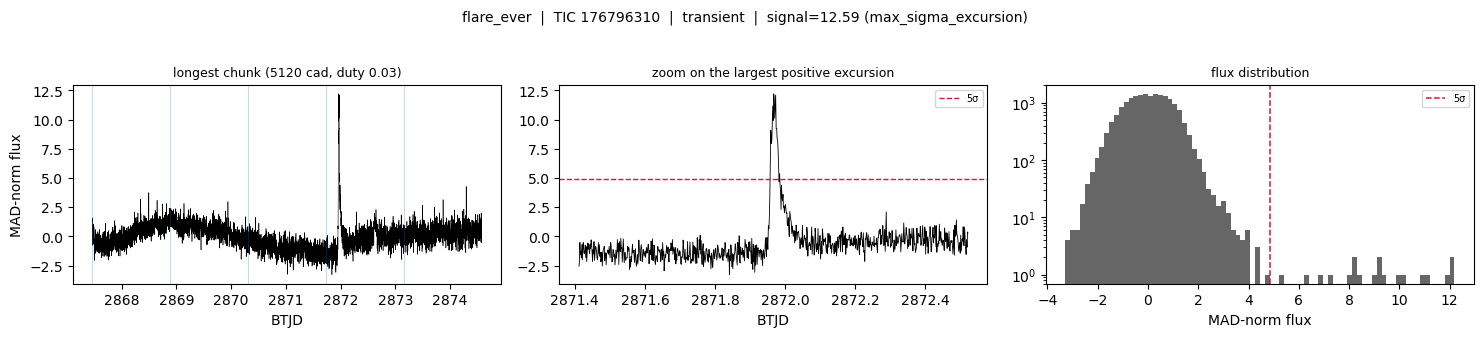

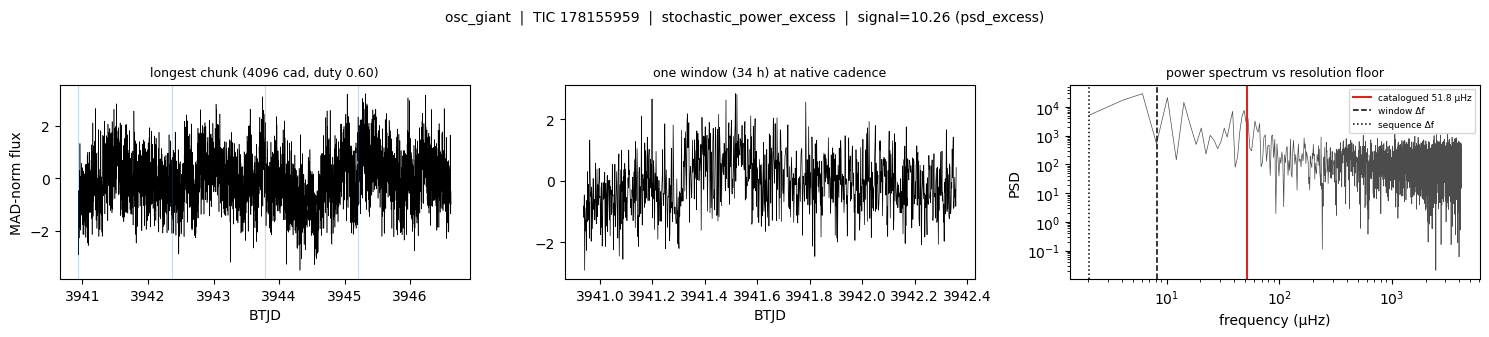

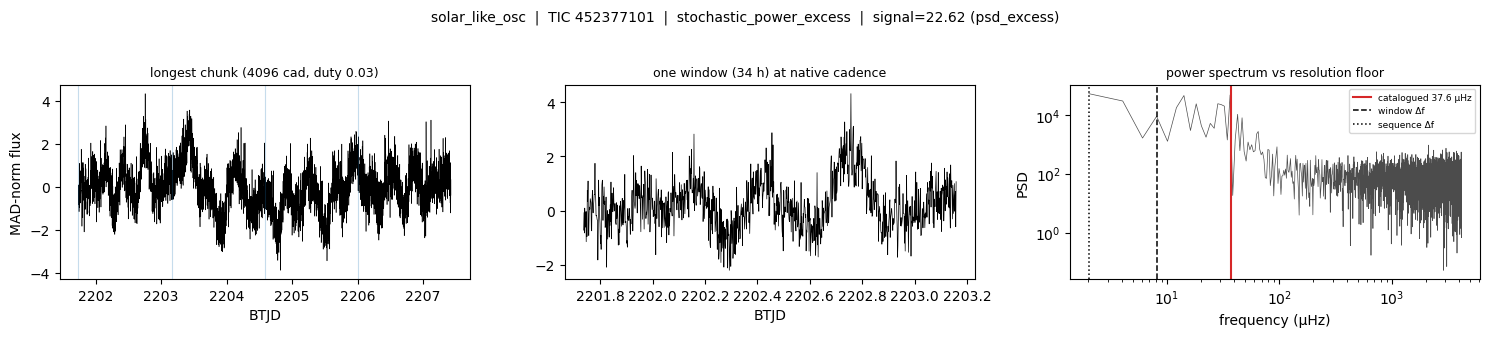

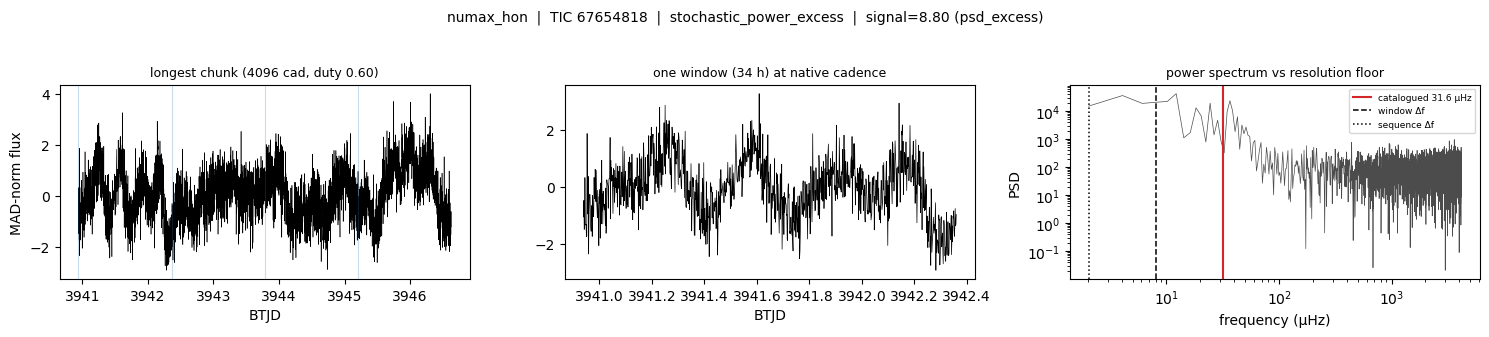

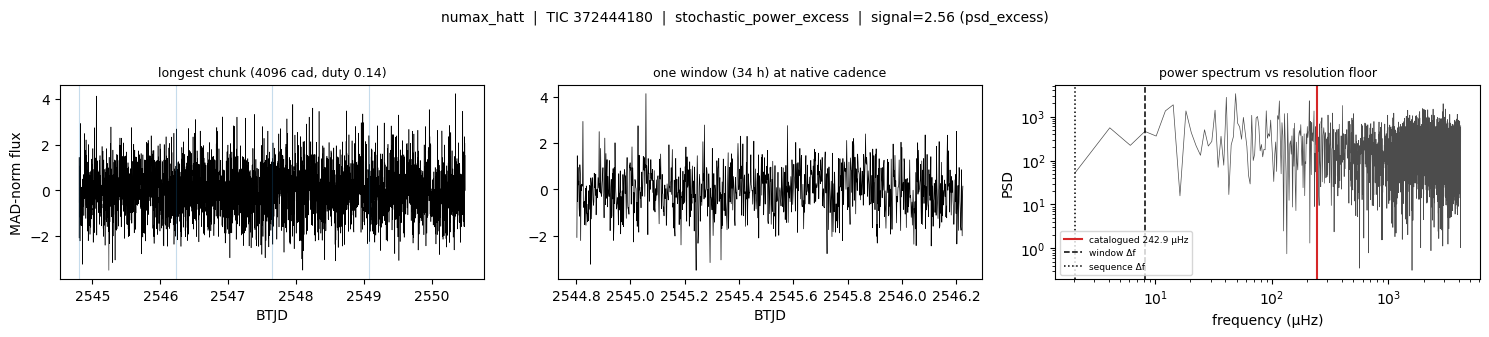

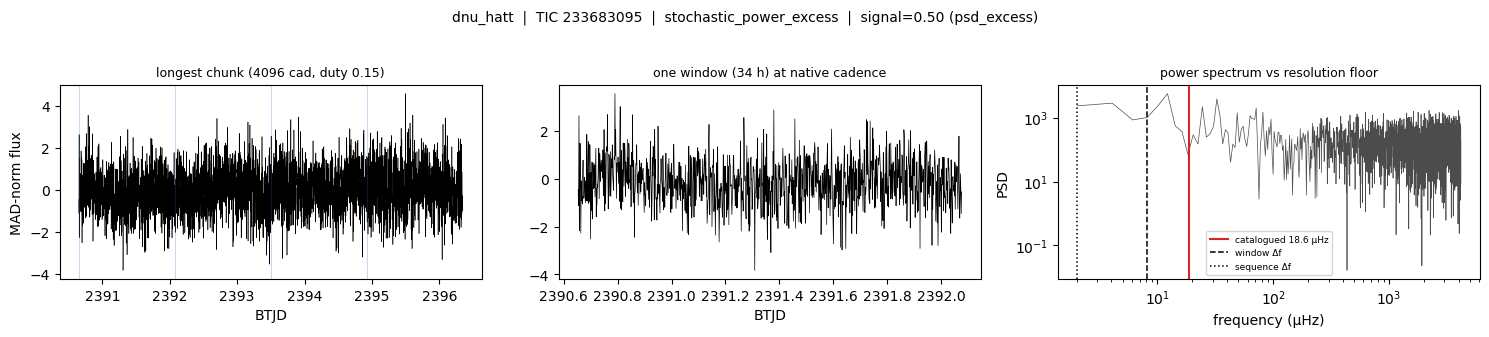

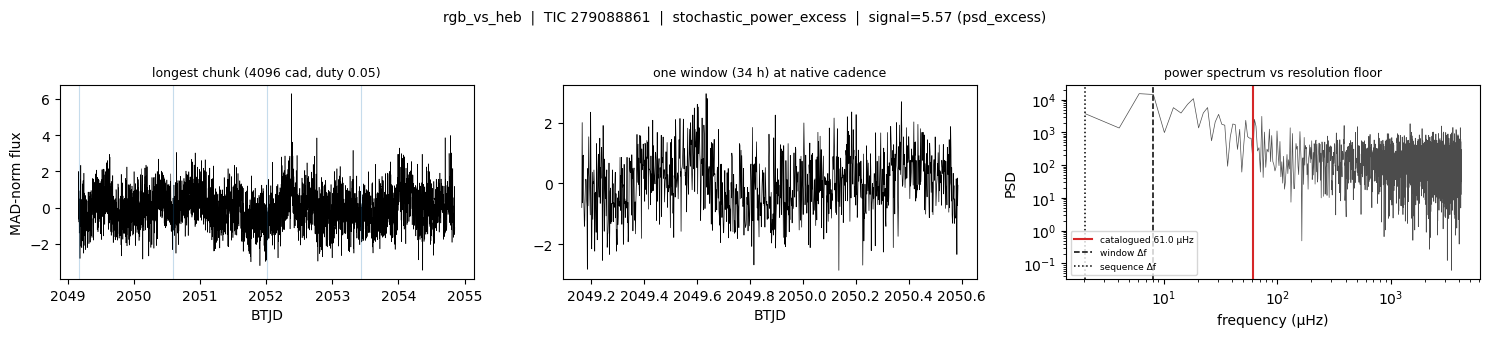

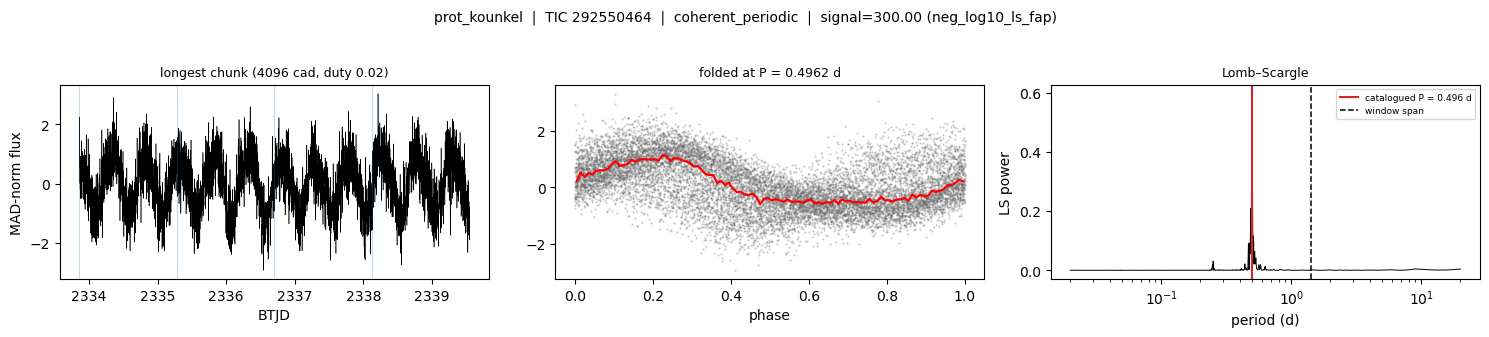

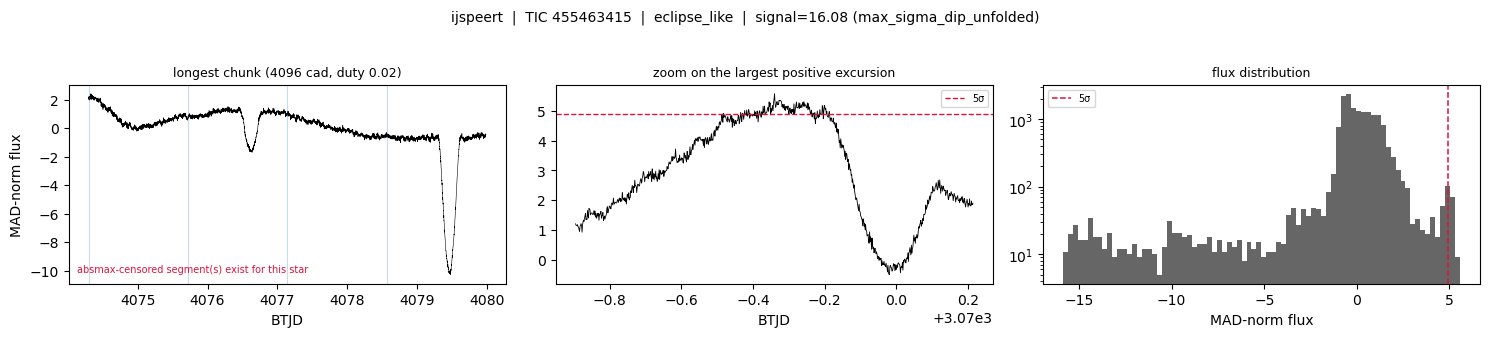

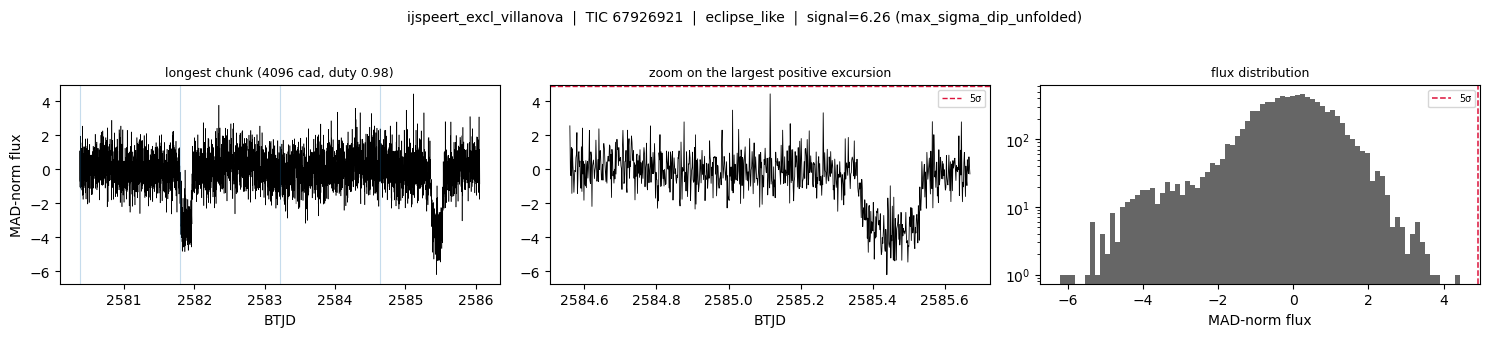

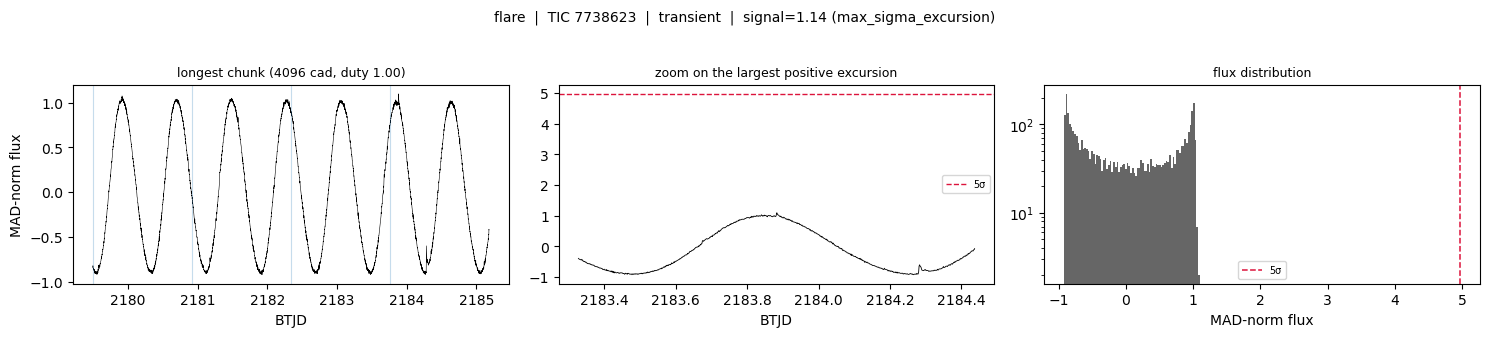

In [19]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample


def gallery_row(task: str):
    r = REG[task]
    d = MEAS.get(task)
    if d is None or not len(d):
        print(f"{task}: no measurements"); return
    cand = d[d.is_pos].dropna(subset=["signal"])
    if not len(cand):
        print(f"{task}: no measurable positives"); return
    row = cand.iloc[rng.integers(len(cand))]
    tic = int(row.tic_id)
    chunks, t, f, _spans = load_star(tic)
    if not len(t):
        print(f"{task}: TIC {tic} has no windows"); return

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
    fig.suptitle(f"{task}  |  TIC {tic}  |  {r['family']}  |  signal={row.signal:.2f} "
                 f"({row.get('signal_metric', '')})", fontsize=10, y=1.04)

    # panel 1 - the longest contiguous chunk, with window boundaries
    ch = max(chunks, key=lambda c: len(c[0]))
    ax[0].plot(ch[0], ch[1], "k-", lw=0.4)
    for k in range(0, len(ch[0]), W):
        ax[0].axvline(ch[0][k], color="tab:blue", alpha=0.25, lw=0.8)
    if tic in cens_tics:
        ax[0].text(0.02, 0.06, "absmax-censored segment(s) exist for this star",
                   transform=ax[0].transAxes, fontsize=7, color="crimson")
    ax[0].set_xlabel("BTJD"); ax[0].set_ylabel("MAD-norm flux")
    ax[0].set_title(f"longest chunk ({len(ch[0])} cad, duty {row.duty_cycle:.2f})", fontsize=9)

    # panel 2 - fold, or zoom for a transient
    P = row.get("period_d", np.nan)
    if np.isfinite(P) and P > 0:
        ph = ((t - t[0]) / P) % 1.0
        ax[1].plot(ph, f, ".", ms=1.2, alpha=0.3, color="0.4")
        nb = 100
        b = np.clip((ph * nb).astype(int), 0, nb - 1)
        prof = np.array([np.median(f[b == k]) if (b == k).sum() >= 3 else np.nan for k in range(nb)])
        ax[1].plot((np.arange(nb) + 0.5) / nb, prof, "r-", lw=1.6)
        ax[1].set_xlabel("phase"); ax[1].set_title(f"folded at P = {P:.4f} d", fontsize=9)
    elif r["family"] == "stochastic_power_excess":
        # no ephemeris to fold; show exactly one window so the reader sees what the
        # encoder's input actually looks like for an oscillator
        s = slice(0, min(len(ch[0]), W))
        ax[1].plot(ch[0][s], ch[1][s], "k-", lw=0.5)
        ax[1].set_xlabel("BTJD")
        ax[1].set_title(f"one window ({WINDOW_SPAN_D * 24:.0f} h) at native cadence", fontsize=9)
    else:
        med, mad = np.median(f), 1.4826 * np.median(np.abs(f - np.median(f)))
        j = int(np.argmax(f))
        s = slice(max(0, j - 400), min(len(f), j + 400))
        ax[1].plot(t[s], f[s], "k-", lw=0.6)
        ax[1].axhline(med + 5 * mad, color="crimson", ls="--", lw=1, label="5σ")
        ax[1].legend(fontsize=7); ax[1].set_xlabel("BTJD")
        ax[1].set_title("zoom on the largest positive excursion", fontsize=9)

    # panel 3 - family diagnostic
    if r["family"] == "stochastic_power_excess":
        from scipy.signal import periodogram
        fr, pw = periodogram(ch[1] - ch[1].mean(), fs=1.0 / CAD_S, scaling="density")
        fu = fr * 1e6
        m = fu > 0
        ax[2].loglog(fu[m], pw[m], "k-", lw=0.5, alpha=0.7)
        if np.isfinite(row.freq_uhz):
            ax[2].axvline(row.freq_uhz, color="tab:red", lw=1.5, label=f"catalogued {row.freq_uhz:.1f} µHz")
        ax[2].axvline(WINDOW_DF_UHZ, color="k", ls="--", lw=1.1, label=f"window Δf")
        ax[2].axvline(SEQ_DF_UHZ, color="k", ls=":", lw=1.1, label=f"sequence Δf")
        ax[2].set_xlabel("frequency (µHz)"); ax[2].set_ylabel("PSD"); ax[2].legend(fontsize=6.5)
        ax[2].set_title("power spectrum vs resolution floor", fontsize=9)
    elif r["family"] == "coherent_periodic" and np.isfinite(P):
        from astropy.timeseries import LombScargle
        ls = LombScargle(t, f)
        fmin, fmax = 1.0 / min(20.0, t.max() - t.min()), 1.0 / 0.02
        freq = np.linspace(fmin, fmax, 4000)
        ax[2].plot(1.0 / freq, ls.power(freq), "k-", lw=0.7)
        ax[2].axvline(P, color="tab:red", lw=1.5, label=f"catalogued P = {P:.3f} d")
        ax[2].axvline(WINDOW_SPAN_D, color="k", ls="--", lw=1.1, label="window span")
        ax[2].set_xscale("log"); ax[2].set_xlabel("period (d)"); ax[2].set_ylabel("LS power")
        ax[2].legend(fontsize=6.5); ax[2].set_title("Lomb–Scargle", fontsize=9)
    else:
        ax[2].hist(f, bins=80, color="0.4")
        ax[2].axvline(np.median(f) + 5 * 1.4826 * np.median(np.abs(f - np.median(f))),
                      color="crimson", ls="--", lw=1.1, label="5σ")
        ax[2].set_yscale("log"); ax[2].set_xlabel("MAD-norm flux"); ax[2].legend(fontsize=7)
        ax[2].set_title("flux distribution", fontsize=9)
    plt.tight_layout(); plt.show()


for task in [r["task"] for r in REGISTRY]:
    gallery_row(task)

## 10. Gate report

Every (task, axis) pair against the pre-registered thresholds. The raw metric sits beside every
verdict, so a badly-chosen threshold is visible rather than silent.

Written to `labels/qc/label_quality_report.csv`. **No label file is touched.**

In [20]:
def verdict(value, fail=None, flag=None, direction="below"):
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return "FLAG"  # unmeasurable is not a pass
    if direction == "below":
        if fail is not None and value < fail:
            return "FAIL"
        if flag is not None and value < flag:
            return "FLAG"
    else:
        if fail is not None and value > fail:
            return "FAIL"
        if flag is not None and value > flag:
            return "FLAG"
    return "PASS"


rep = []


def add(task, axis, metric, value, v, note=""):
    rep.append({"task": task, "family": REG[task]["family"], "axis": axis,
                "metric": metric, "value": value, "verdict": v, "note": note})


gs = GATES["generic"]
for _, r in SUPPORT.iterrows():
    add(r.task, "support", "n_test_pos", r.n_test_pos,
        verdict(r.n_test_pos, gs["support"]["fail_below"], gs["support"]["flag_below"], "below"),
        f"prevalence inflated {r.prev_inflation:.1f}x vs corpus" if np.isfinite(r.prev_inflation) else "")

for _, r in OVERLAP.iterrows():
    add(r.task, "overlap", "max_jaccard", round(float(r.max_jaccard), 4),
        verdict(r.max_jaccard, gs["overlap"]["fail_above"], gs["overlap"]["flag_above"], "above"),
        f"partner={r.partner}, n_shared={r.n_shared}")

for _, r in CONTAM.iterrows():
    add(r.task, "negative_pool", "frac_quiet_with_signal", round(float(r.frac_neg_with_signal), 4),
        verdict(r.frac_neg_with_signal, gs["negative_pool_contamination"]["fail_above"],
                gs["negative_pool_contamination"]["flag_above"], "above"),
        f"n_neg={int(r.n_neg)}")

for _, r in REDUNDANCY.iterrows():
    add(r.target, "target_redundancy", "abs_r_vs_predictor", round(float(r.raw_abs_r), 4),
        verdict(r.raw_abs_r, gs["target_redundancy"]["fail_above"],
                gs["target_redundancy"]["flag_above"], "above"),
        f"predictor={r.predictor}, law explains {r.frac_variance_explained_by_law:.1%} of variance")

gcp = GATES["families"]["coherent_periodic"]["period_containment"]
for _, r in CONTAINMENT.iterrows():
    add(r.task, "period_containment", f"frac_P<=w{W}", round(float(r[f"w{W}"]), 4),
        verdict(r[f"w{W}"], gcp["fail_below"], gcp["flag_below"], "below"),
        f"median P = {r.median_P_h:.1f} h vs window {WINDOW_SPAN_D * 24:.1f} h")

gfr = GATES["families"]["stochastic_power_excess"]["frequency_resolvability"]
n_df = gfr["n_delta_f"]
for _, r in FREQ_RES.iterrows():
    add(r.task, "frequency_resolvability", f"frac_freq>={n_df}df_window",
        round(float(r[f"frac_ge_{n_df}df_window"]), 4),
        verdict(r[f"frac_ge_{n_df}df_window"], gfr["fail_below"], gfr["flag_below"], "below"),
        f"median {r.median_freq_uhz:.1f} µHz; window Δf={WINDOW_DF_UHZ:.2f}, seq Δf={SEQ_DF_UHZ:.2f}")

gcv = GATES["families"]["eclipse_like"]["coverage_ratio"]
for _, r in COVERAGE.iterrows():
    if not r.get("n_with_ephemeris"):
        add(r.task, "coverage_ratio", "median_obs_over_expected", np.nan, "FLAG",
            "no ephemeris available for this catalog - axis unmeasurable")
        continue
    add(r.task, "coverage_ratio", "median_obs_over_expected", round(float(r.median_cov_ratio), 4),
        verdict(r.median_cov_ratio, gcv["fail_below"], gcv["flag_below"], "below"),
        f"95% CI [{r.ci_lo:.2f}, {r.ci_hi:.2f}], t0 from {r.t0_source}, "
        f"{r.frac_stars_zero_events:.0%} of stars caught zero events; "
        f"we hold {r.median_baseline_frac:.0%} of the full baseline "
        f"({r.median_sectors_held:.0f} sectors)")

for _, r in SIGNAL.iterrows():
    gsig = GATES["families"][r.family]["signal_snr"]
    v = verdict(r.frac_pos_pass, gsig["fail_below"], gsig["flag_below"], "below")
    note = (f"95% CI [{r.ci_lo:.2f}, {r.ci_hi:.2f}]"
            + (f"; quiet pass {r.frac_neg_pass:.2f}" if np.isfinite(r.frac_neg_pass) else ""))
    if r.is_fallback:
        # the pre-registered threshold was written for a folded SNR; applying it to
        # an unfolded dip would be a different test wearing the same number
        v = "FLAG"
        note += f"; UNFOLDED FALLBACK ({r.metric_used}) - no catalogued period, gate not applicable"
    add(r.task, "signal_presence", f"frac_pos_pass({r.metric_used}>={r.threshold:g})",
        round(float(r.frac_pos_pass), 4), v, note)

for _, r in CENSOR.iterrows():
    gcen = GATES["families"][r.family]["censoring"]
    v = verdict(r.enrichment, gcen["fail_above"], gcen["flag_above"], "above")
    if r.n_censored < 5 and v == "FAIL":
        v = "FLAG"
    add(r.task, "censoring", "absmax_enrichment", round(float(r.enrichment), 3), v,
        f"{int(r.n_censored)} censored of {int(r.n_pos_with_windows)} ({r.evidence})")

for dfr in GATES["deferred"]:
    for r in REGISTRY:
        add(r["task"], dfr["axis"], f"proxy: {dfr['proxy_used']}", np.nan, "FLAG",
            "not measurable without MAST re-download; bounded by duty cycle only")

REPORT = pd.DataFrame(rep)
REPORT.to_csv(QC / "label_quality_report.csv", index=False)

piv = REPORT.pivot_table(index="task", columns="axis", values="verdict", aggfunc="first").fillna("N/A")
display(piv)
print(REPORT.verdict.value_counts().to_string())
print(f"\nwritten -> {QC / 'label_quality_report.csv'}")

axis,censoring,class_b_c_window_loss,coverage_ratio,frequency_resolvability,negative_pool,overlap,period_containment,signal_presence,support,target_redundancy
task,,,,,,,,,,
dnu_hatt,PASS,FLAG,N/A,FAIL,FLAG,FAIL,N/A,FAIL,PASS,FAIL
eb,FAIL,FLAG,PASS,N/A,FLAG,PASS,N/A,FAIL,PASS,N/A
flare,FAIL,FLAG,N/A,N/A,FAIL,PASS,N/A,FAIL,FLAG,N/A
flare_ever,FAIL,FLAG,N/A,N/A,FAIL,PASS,N/A,FAIL,FAIL,N/A
ijspeert,FAIL,FLAG,FLAG,N/A,PASS,FAIL,N/A,FLAG,FAIL,N/A
ijspeert_excl_villanova,FAIL,FLAG,FLAG,N/A,PASS,FAIL,N/A,FLAG,FAIL,N/A
numax_hatt,PASS,FLAG,N/A,PASS,FLAG,FAIL,N/A,PASS,PASS,N/A
numax_hon,PASS,FLAG,N/A,PASS,FLAG,FAIL,N/A,PASS,PASS,N/A
osc_giant,PASS,FLAG,N/A,PASS,FLAG,FAIL,N/A,PASS,PASS,N/A


verdict
PASS    44
FLAG    35
FAIL    32

written -> C:\git_repo\Stellar-World-Model\labels\qc\label_quality_report.csv


,n_fail,n_flag,severity,standing
task,,,,
dnu_hatt,4,1,9,do not report without a caveat
flare_ever,4,0,8,do not report without a caveat
ijspeert_excl_villanova,3,2,8,do not report without a caveat
ijspeert,3,2,8,do not report without a caveat
flare,3,1,7,do not report without a caveat
rotation_period,3,1,7,do not report without a caveat
rotation,3,1,7,do not report without a caveat
eb,2,1,5,do not report without a caveat
transit,2,1,5,do not report without a caveat


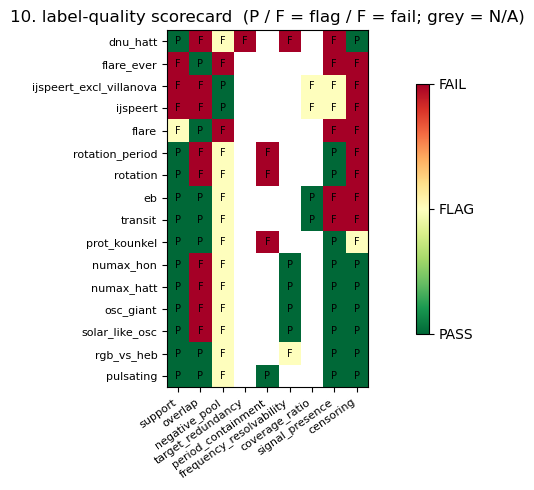

In [21]:
# headline: which probes are trustworthy as-is?
sev = {"FAIL": 2, "FLAG": 1, "PASS": 0, "N/A": 0}
sc = (REPORT[~REPORT.axis.str.contains("class_b_c")]
      .assign(s=lambda d: d.verdict.map(sev))
      .groupby("task")
      .agg(n_fail=("verdict", lambda s: (s == "FAIL").sum()),
           n_flag=("verdict", lambda s: (s == "FLAG").sum()),
           severity=("s", "sum"))
      .sort_values("severity", ascending=False))
sc["standing"] = np.where(sc.n_fail >= 2, "do not report without a caveat",
                   np.where(sc.n_fail == 1, "caveat one axis",
                     np.where(sc.n_flag > 0, "usable, watch flags", "clean")))
display(sc)

fig, ax = plt.subplots(figsize=(10, 5))
axes_order = [a for a in REPORT.axis.unique() if "class_b_c" not in a]
M = (REPORT[REPORT.axis.isin(axes_order)]
     .pivot_table(index="task", columns="axis", values="verdict", aggfunc="first")
     .reindex(index=sc.index, columns=axes_order))
num = M.apply(lambda s: s.map({"PASS": 0.0, "FLAG": 1.0, "FAIL": 2.0}))
im = ax.imshow(num.values, cmap="RdYlGn_r", vmin=0, vmax=2)
ax.set_xticks(range(len(axes_order))); ax.set_xticklabels(axes_order, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=8)
for i in range(M.shape[0]):
    for k in range(M.shape[1]):
        v = M.values[i, k]
        if isinstance(v, str):
            ax.text(k, i, v[0], ha="center", va="center", fontsize=7)
cb = plt.colorbar(im, ax=ax, shrink=0.7, ticks=[0, 1, 2]); cb.ax.set_yticklabels(["PASS", "FLAG", "FAIL"])
ax.set_title("10. label-quality scorecard  (P / F = flag / F = fail; grey = N/A)")
plt.tight_layout(); plt.savefig(FIGS / "10_scorecard.png", dpi=120, bbox_inches="tight"); plt.show()

## 11. Join to exp05 probe scores — interpretive

The gates above were fixed before this section existed, so nothing here can have influenced them.

The hypothesis worth stating plainly: **the probes with the largest apparent SSL wins may be the
probes with the worst label hygiene.** Two candidates were visible before any measurement —
`dnu_hatt` (sub-resolution target riding a scaling relation) and `ijspeert_excl_villanova`
(n_pos=19, PR-AUC 0.052→0.332 across seeds).

If that pattern holds, the trained−untrained gap is partly a measure of which tasks have exploitable
label artifacts, and the affected probes need a caveat before the ML4PS freeze.

,trained_mean,trained_sd,n_seeds,untrained,gap,n_fail,n_flag,severity,standing,n_test_pos
task,,,,,,,,,,
numax_hon,0.7928,0.0047,4,0.4299,0.3629,1,1,3,caveat one axis,1313
rotation_period,0.6477,0.0277,4,0.3769,0.2708,3,1,7,do not report without a caveat,180
prot_kounkel,0.3472,0.0469,4,0.1188,0.2284,1,2,4,caveat one axis,159
ijspeert_excl_villanova,0.2604,0.0212,4,0.0808,0.1796,3,2,8,do not report without a caveat,18
osc_giant,0.8450,0.0114,4,0.7160,0.1290,1,1,3,caveat one axis,1313
numax_hatt,0.8299,0.0048,4,0.7079,0.1220,1,1,3,caveat one axis,417
solar_like_osc,0.3134,0.0191,4,0.1953,0.1181,1,1,3,caveat one axis,417
dnu_hatt,0.8217,0.0053,4,0.7039,0.1178,4,1,9,do not report without a caveat,417
ijspeert,0.4430,0.0134,4,0.3776,0.0654,3,2,8,do not report without a caveat,20


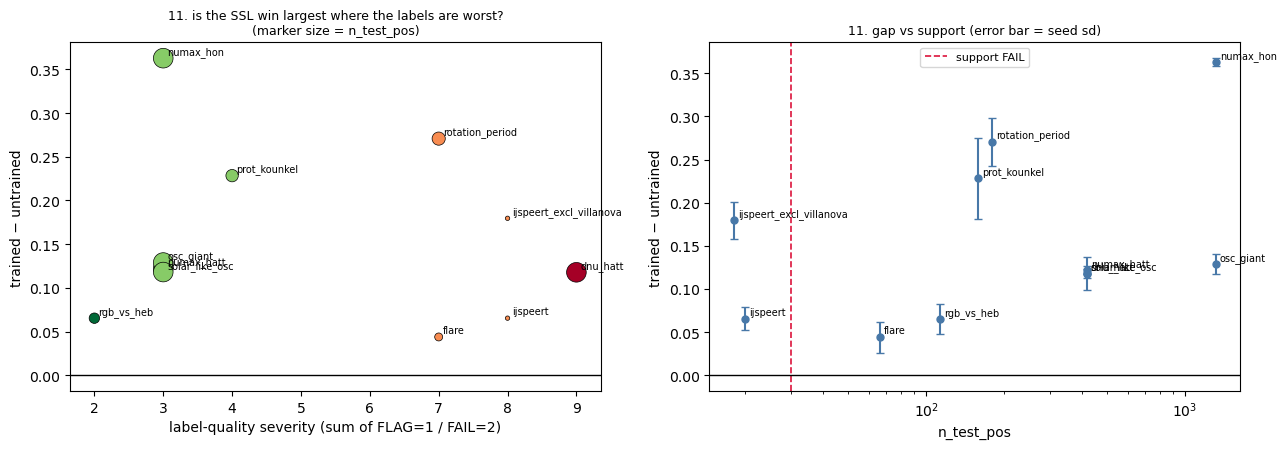

Spearman(severity, gap) = -0.070  p = 0.838   n = 11
Not distinguishable from no relationship at this n. The hypothesis is neither supported nor refuted -- report it as untested, not as a null result.
n = 11 probes either way -- this is a direction to follow up, not a result.


In [22]:
SCORE = pd.read_csv(ROOT / "experiments" / "new_task_exp05" / "new_task_scorecard.csv")
SCORE["metric"] = np.where(SCORE.pr_auc.notna(), SCORE.pr_auc, SCORE.r2)
best = SCORE[SCORE.pooling == "mean"] if "pooling" in SCORE else SCORE

trained = best[best.arm.str.startswith("comb_fbwd")].groupby("task")["metric"].agg(["mean", "std", "count"])
untr = best[best.arm == "untrained"].groupby("task")["metric"].mean()
GAP = trained.join(untr.rename("untrained")).assign(gap=lambda d: d["mean"] - d.untrained)
GAP = GAP.rename(columns={"mean": "trained_mean", "std": "trained_sd", "count": "n_seeds"})

J = GAP.join(sc[["n_fail", "n_flag", "severity", "standing"]], how="left")
J = J.join(SUPPORT.set_index("task")[["n_test_pos"]], how="left")
display(J.round(4).sort_values("gap", ascending=False))

jj = J.dropna(subset=["gap", "severity"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].scatter(jj.severity, jj.gap, s=np.clip(jj.n_test_pos.fillna(30), 20, 400) / 2,
              c=jj.n_fail, cmap="RdYlGn_r", edgecolor="k", lw=0.5)
for t, r in jj.iterrows():
    ax[0].annotate(t, (r.severity, r.gap), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax[0].axhline(0, color="k", lw=1)
ax[0].set_xlabel("label-quality severity (sum of FLAG=1 / FAIL=2)")
ax[0].set_ylabel("trained − untrained")
ax[0].set_title("11. is the SSL win largest where the labels are worst?\n(marker size = n_test_pos)", fontsize=9)

ax[1].errorbar(jj.n_test_pos, jj.gap, yerr=jj.trained_sd, fmt="o", ms=5, capsize=3, color="#4878a8")
for t, r in jj.iterrows():
    ax[1].annotate(t, (r.n_test_pos, r.gap), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax[1].axvline(GATES["generic"]["support"]["fail_below"], color="crimson", ls="--", lw=1.2, label="support FAIL")
ax[1].set_xscale("log"); ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("n_test_pos"); ax[1].set_ylabel("trained − untrained")
ax[1].set_title("11. gap vs support (error bar = seed sd)", fontsize=9); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "11_gap_vs_quality.png", dpi=120, bbox_inches="tight"); plt.show()

if len(jj) >= 4:
    from scipy.stats import spearmanr
    rho, p = spearmanr(jj.severity, jj.gap)
    print(f"Spearman(severity, gap) = {rho:+.3f}  p = {p:.3f}   n = {len(jj)}")
    if p >= 0.05:
        print("Not distinguishable from no relationship at this n. The hypothesis is neither "
              "supported nor refuted -- report it as untested, not as a null result.")
    elif rho > 0:
        print("Positive and significant: the largest SSL wins do sit on the worst-audited probes. "
              "Every affected probe needs a caveat before the ML4PS freeze.")
    else:
        print("Negative and significant: the SSL wins are NOT concentrated on badly-audited "
              "probes, which is evidence against the artifact explanation.")
    print(f"n = {len(jj)} probes either way -- this is a direction to follow up, not a result.")

### Outputs

| file | what |
|---|---|
| `labels/qc/label_quality_report.csv` | one row per (task, axis) with metric, verdict, note |
| `labels/qc/label_matrix.parquet` | derived `tic_id × task` view, mtime-stamped — a view, never a source |
| `labels/qc/cache/*.parquet` | per-task measurements + the npz file index |
| `labels/qc/figs/*.png` | every figure above |

**Not done here, on the record:** exact Class-B/C window loss needs a MAST re-download and
re-segmentation per `/astroquery-resilience`; duty cycle only bounds it. Recorded under `deferred:`
in the gate manifest.

**Nothing in this notebook writes a label file.** Acting on a FAIL means an eval-time
`readout_sweep --labels-version` override plus an ADR, deliberately kept as a separate decision.